## 0. 패키지 설치 & 환경 설정

In [2]:
# ── 패키지 설치 (이미 설치되어 있으면 건너뜀) ──
import subprocess, sys

def install_if_missing(package: str):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

install_if_missing("numpy")
install_if_missing("matplotlib")
install_if_missing("scipy")

# ── import ──
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import logsumexp

# ── 한글 폰트 설정 (Windows: Malgun Gothic) ──
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 전역 시각화 스타일 ──
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print("환경 설정 완료 ✓")

환경 설정 완료 ✓


## 1. 혼동행렬(Confusion Matrix) 생성

각 어노테이터의 응답 특성을 **혼동행렬**로 모델링합니다.

**Dirichlet 분포** 기반으로 각 행(정답 클래스)마다 확률분포를 생성:

$$C_i[m, :] \sim \text{Dirichlet}(\alpha_1, \dots, \alpha_K)$$

- `diag_alpha` (대각선 가중치): 클수록 정답 응답 확률 ↑ → 정확한 어노테이터
- `off_alpha` (비대각선 가중치): 오답 분포의 균등도 제어

In [3]:
def generate_confusion_matrix(num_classes, diag_alpha=10.0, off_alpha=1.0, seed=None):
    """
    Dirichlet 분포 기반 혼동행렬 생성.
    각 행의 합 = 1 (확률 분포).

    Parameters:
        num_classes: 클래스 수 K (K×K 행렬 생성)
        diag_alpha:  대각선 가중치 (높을수록 정답 확률 ↑)
        off_alpha:   비대각선 가중치 (오답 분포)
        seed:        재현성 시드
    Returns:
        np.ndarray: (K, K) 혼동행렬
    """
    rng = np.random.default_rng(seed)
    cm = np.zeros((num_classes, num_classes))
    for i in range(num_classes):
        alpha = np.full(num_classes, off_alpha)
        alpha[i] = diag_alpha         # 정답 위치만 높은 가중치
        cm[i] = rng.dirichlet(alpha)  # 합이 1인 확률 벡터
    return cm


print("혼동행렬 생성 함수 정의 완료 ✓")

혼동행렬 생성 함수 정의 완료 ✓


## 2. 파라미터 설정 (숙련도·인원 수 설정)

다양한 숙련도를 가진 어노테이터 집단을 구성합니다.
- **전문가**: `diag_alpha=50.0` → 거의 항상 정답 (정답률 ~90%+)
- **중급자**: `diag_alpha=5.0` → 적당한 오답 존재 (정답률 ~50%)
- **초보자**: `diag_alpha=1.5` → 거의 랜덤 수준 (정답률 ~25%)

In [4]:
# ═══════════════════════════════════════════
#  공통 파라미터 설정 (여기서만 수정)
# ═══════════════════════════════════════════

# 기본 실험 파라미터
NUM_CLASSES = 6        # 분류 클래스 수 K
NUM_SAMPLES = 5000     # 테스트 샘플 수
SEED = 42              # 기본 재현성 시드
SEED_LIST = [42, 52, 62, 72, 82, 92, 102, 112, 122, 132]  # 다중 시드용(10개)

# 평가 프로토콜 고정
MAJORITY_TIE_BREAK = 'lowest'  # 'lowest' | 'random'
SUBSET_REPEATS_SMALL_N = 1     # 반복 비활성(시드만 사용)
SUBSET_REPEATS_LARGE_N = 1     # 반복 비활성(시드만 사용)
SMALL_N_CUTOFF = 10            # 작은 n 기준

# # dirichlet 모드 어노테이터 구성: {이름: (인원 수, diag_alpha)}
# ANNOTATOR_CONFIG = {
#     "전문가 (α=50.0)": (10, 50.0),
#     "중급자 (α=5.0)":  (37, 5.0),
#     "초보자 (α=1.5)":  (53, 1.5),
# }
ANNOTATOR_CONFIG = {}
OFF_ALPHA = 1.0  # dirichlet 모드 비대각선 기본 가중치

# target_accuracy 모드 어노테이터 구성: {이름: (인원 수, target_accuracy)}
# target_accuracy 값은 [0.1, 0.9] 범위를 권장
TARGET_ANNOTATOR_CONFIG = {
    "전문가 ": (0, 0.70),
    "중급자 ": (20, 0.30),
    "초보자 ": (0, 0.20),
}

# 혼동행렬 생성 설정
CM_GENERATION_MODE = 'target_accuracy'         # 'dirichlet' | 'target_accuracy'
TARGET_ACC = 0.3                               # target 구성 미지정 시 fallback 정확도
ACCURACY_MODE = 'uniform_weighted'             # 'per_class_exact' | 'uniform_weighted'
TARGET_BASE_DIAG_ALPHA = 1.0                   # weighted 모드 기본 대각 패턴 생성용
DIAG_SPREAD = 5.0                             # weighted 모드 클래스별 편차 크기
TARGET_OFFDIAG_ALPHA = 10.0                    # 오답 분배 Dirichlet 농도

# 정답 라벨 생성 분포 설정
CLASS_DIST_MODE = 'custom'                     # 'uniform' | 'custom'
CUSTOM_CLASS_PROBS = np.array([0.35, 0.25, 0.15, 0.10, 0.10, 0.05], dtype=float)

# 디버그 설정
DEBUG_SAMPLE_IDX = 34                          # None이면 MAP/MLE 불일치 첫 샘플 자동 선택
SHOW_ANNOTATOR_TERMS = False                   # True면 디버그 출력 상세화

print("공통 파라미터 설정 완료 ✓")
print(f"프로토콜: tie_break={MAJORITY_TIE_BREAK}")

공통 파라미터 설정 완료 ✓
프로토콜: tie_break=lowest


In [5]:
def build_offdiag_row(correct_idx, diag_prob, num_classes, offdiag_alpha=1.0, rng=None):
    """
    단일 행(row)에서 대각 원소를 diag_prob로 고정하고,
    나머지 확률(1 - diag_prob)을 Dirichlet 기반으로 오답 클래스에 배분.
    """
    if num_classes < 2:
        raise ValueError("num_classes는 2 이상이어야 합니다.")
    if not (0.0 <= float(diag_prob) <= 1.0):
        raise ValueError("diag_prob는 [0, 1] 범위여야 합니다.")
    if not (0 <= int(correct_idx) < int(num_classes)):
        raise ValueError("correct_idx가 유효 범위를 벗어났습니다.")
    if offdiag_alpha <= 0:
        raise ValueError("offdiag_alpha는 0보다 커야 합니다.")

    if rng is None:
        rng = np.random.default_rng()

    diag_prob = float(diag_prob)
    row = np.zeros(num_classes, dtype=float)
    remain = 1.0 - diag_prob

    alpha = np.full(num_classes - 1, float(offdiag_alpha), dtype=float)
    off_probs = rng.dirichlet(alpha)
    off_indices = [j for j in range(num_classes) if j != correct_idx]

    for j, p in zip(off_indices, off_probs):
        row[j] = remain * p
    row[correct_idx] = diag_prob
    return row


def _compute_center_scale_upper(centered, target_acc):
    """target_acc + s * centered가 [0, 1]을 만족하는 s의 상한 계산."""
    ub = np.inf
    for v in centered:
        if v > 0:
            ub = min(ub, (1.0 - target_acc) / v)
        elif v < 0:
            ub = min(ub, (0.0 - target_acc) / v)
    if not np.isfinite(ub):
        ub = 0.0
    return max(0.0, float(ub))


def generate_target_accuracy_confusion_matrix(
    num_classes,
    target_acc,
    accuracy_mode='per_class_exact',
    base_diag_alpha=3.0,
    diag_spread=0.7,
    offdiag_alpha=1.0,
    seed=None,
):
    """
    목표 정확도 정의에 맞는 (K, K) 혼동행렬 생성.

    accuracy_mode:
        - per_class_exact: 모든 클래스의 diag 확률을 target_acc로 고정
        - uniform_weighted: mean(diag(C)) = target_acc
    """
    if num_classes < 2:
        raise ValueError("num_classes는 2 이상이어야 합니다.")
    if not (0.1 <= float(target_acc) <= 0.9):
        raise ValueError("target_acc는 [0.1, 0.9] 범위를 권장/지원합니다.")

    target_acc = float(target_acc)
    rng = np.random.default_rng(seed)

    if accuracy_mode == 'per_class_exact':
        diag_probs = np.full(num_classes, target_acc, dtype=float)
    else:
        if base_diag_alpha <= 0:
            raise ValueError("base_diag_alpha는 0보다 커야 합니다.")
        if diag_spread < 0:
            raise ValueError("diag_spread는 0 이상이어야 합니다.")

        base_cm = generate_confusion_matrix(
            num_classes=num_classes,
            diag_alpha=float(base_diag_alpha),
            off_alpha=float(max(offdiag_alpha, 1e-12)),
            seed=seed,
        )
        pattern = np.diag(base_cm).astype(float)

        if accuracy_mode == 'uniform_weighted':
            weights = np.ones(num_classes, dtype=float) / num_classes
        else:
            raise ValueError("accuracy_mode는 'per_class_exact'|'uniform_weighted' 이어야 합니다.")

        centered = pattern - float(np.dot(weights, pattern))
        scale_ub = _compute_center_scale_upper(centered, target_acc)
        scale = min(float(diag_spread), float(scale_ub))
        diag_probs = target_acc + scale * centered
        diag_probs = np.clip(diag_probs, 0.0, 1.0)

    cm = np.zeros((num_classes, num_classes), dtype=float)
    for c in range(num_classes):
        cm[c] = build_offdiag_row(
            correct_idx=c,
            diag_prob=float(diag_probs[c]),
            num_classes=num_classes,
            offdiag_alpha=offdiag_alpha,
            rng=rng,
        )

    # 수치 오차 정리
    cm = np.clip(cm, 0.0, 1.0)
    cm = cm / cm.sum(axis=1, keepdims=True)
    return cm


def build_class_probs(num_classes, class_dist_mode='uniform', custom_class_probs=None):
    """정답 라벨 생성에 사용할 클래스 분포 벡터 생성/검증."""
    if class_dist_mode == 'uniform':
        return np.ones(num_classes, dtype=float) / num_classes

    if class_dist_mode == 'custom':
        if custom_class_probs is None:
            raise ValueError("custom 모드에서는 custom_class_probs가 필요합니다.")
        class_probs = np.asarray(custom_class_probs, dtype=float).copy()
        if len(class_probs) != num_classes:
            raise ValueError(f"CUSTOM_CLASS_PROBS 길이({len(class_probs)})는 NUM_CLASSES({num_classes})와 같아야 합니다.")
        if np.any(class_probs < 0):
            raise ValueError("CUSTOM_CLASS_PROBS에는 음수가 포함될 수 없습니다.")
        s = class_probs.sum()
        if s <= 0:
            raise ValueError("CUSTOM_CLASS_PROBS 합은 0보다 커야 합니다.")
        return class_probs / s

    raise ValueError("CLASS_DIST_MODE는 'uniform' 또는 'custom' 이어야 합니다.")


def expand_diag_alphas(annotator_config):
    """ANNOTATOR_CONFIG를 어노테이터별 diag alpha 리스트로 펼침."""
    diag_alphas = []
    for _, (count, alpha) in annotator_config.items():
        diag_alphas.extend([alpha] * int(count))
    return diag_alphas


def expand_target_accs(target_annotator_config):
    """TARGET_ANNOTATOR_CONFIG를 어노테이터별 target_acc 리스트로 펼침."""
    target_accs = []
    for _, (count, target_acc) in target_annotator_config.items():
        target_accs.extend([target_acc] * int(count))
    return target_accs


def generate_annotator_confusion_matrices(
    num_classes,
    annotator_config,
    seed,
    cm_generation_mode='dirichlet',
    off_alpha=1.0,
    target_acc=0.5,
    target_annotator_config=None,
    accuracy_mode='per_class_exact',
    target_base_diag_alpha=3.0,
    diag_spread=0.7,
    target_offdiag_alpha=1.0,
):
    """
    어노테이터 구성과 모드에 따라 혼동행렬 리스트 생성.

    Returns:
        confusion_matrices, diag_alphas, num_annotators
    """
    rng_seed = np.random.default_rng(seed)
    confusion_matrices = []

    if cm_generation_mode == 'dirichlet':
        diag_alphas = expand_diag_alphas(annotator_config)
        num_annotators = len(diag_alphas)
        if num_annotators <= 0:
            raise ValueError("어노테이터 수가 0입니다. ANNOTATOR_CONFIG를 확인해주세요.")

        for i in range(num_annotators):
            ann_seed = int(rng_seed.integers(0, 2**31))
            cm = generate_confusion_matrix(
                num_classes=num_classes,
                diag_alpha=diag_alphas[i],
                off_alpha=off_alpha,
                seed=ann_seed,
            )
            confusion_matrices.append(cm)

    elif cm_generation_mode == 'target_accuracy':
        if target_annotator_config is None:
            target_accs = [target_acc] * len(expand_diag_alphas(annotator_config))
        else:
            target_accs = expand_target_accs(target_annotator_config)

        num_annotators = len(target_accs)
        if num_annotators <= 0:
            raise ValueError("어노테이터 수가 0입니다. TARGET_ANNOTATOR_CONFIG를 확인해주세요.")

        # 하위 호환: 기존 셀에서 diag_alphas 이름을 계속 사용
        diag_alphas = [float(acc) for acc in target_accs]

        for i in range(num_annotators):
            ann_seed = int(rng_seed.integers(0, 2**31))
            cm = generate_target_accuracy_confusion_matrix(
                num_classes=num_classes,
                target_acc=float(target_accs[i]),
                accuracy_mode=accuracy_mode,
                base_diag_alpha=target_base_diag_alpha,
                diag_spread=diag_spread,
                offdiag_alpha=target_offdiag_alpha,
                seed=ann_seed,
            )
            confusion_matrices.append(cm)

    else:
        raise ValueError("CM_GENERATION_MODE는 'dirichlet' 또는 'target_accuracy' 이어야 합니다.")

    # 기본 검증: 행 합 1, 값 범위 [0,1]
    for cm in confusion_matrices:
        if not np.allclose(cm.sum(axis=1), 1.0, atol=1e-8):
            raise ValueError("혼동행렬 행 합이 1이 아닙니다.")
        if np.any(cm < -1e-12) or np.any(cm > 1.0 + 1e-12):
            raise ValueError("혼동행렬 원소가 [0,1] 범위를 벗어났습니다.")

    return confusion_matrices, diag_alphas, num_annotators


def simulate_responses(confusion_matrices, true_labels, seed=None):
    """
    전체 데이터셋에 대해 모든 어노테이터의 응답을 시뮬레이션.

    Parameters:
        confusion_matrices: 어노테이터별 (K,K) 혼동행렬 리스트
        true_labels:        (num_samples,) 정답 라벨 배열
        seed:               랜덤 시드
    Returns:
        np.ndarray: (num_samples, num_annotators) 응답 행렬
    """
    rng = np.random.default_rng(seed)
    num_samples = len(true_labels)
    num_ann = len(confusion_matrices)
    responses = np.zeros((num_samples, num_ann), dtype=int)

    for s in range(num_samples):
        tc = true_labels[s]
        for i in range(num_ann):
            responses[s, i] = rng.choice(confusion_matrices[i].shape[0], p=confusion_matrices[i][tc])
    return responses


print("생성/시뮬레이션 보조 함수 정의 완료 ✓")

생성/시뮬레이션 보조 함수 정의 완료 ✓


In [6]:
# ═══════════════════════════════════════════
#  어노테이터 혼동행렬 생성 (공통 함수 사용)
# ═══════════════════════════════════════════

# target_accuracy 모드에서는 그룹별 (인원 수, target_acc) 설정 사용
target_cfg = TARGET_ANNOTATOR_CONFIG if CM_GENERATION_MODE == 'target_accuracy' else None

confusion_matrices, diag_alphas, num_annotators = generate_annotator_confusion_matrices(
    num_classes=NUM_CLASSES,
    annotator_config=ANNOTATOR_CONFIG,
    seed=SEED,
    cm_generation_mode=CM_GENERATION_MODE,
    off_alpha=OFF_ALPHA,
    target_acc=TARGET_ACC,
    target_annotator_config=target_cfg,
    accuracy_mode=ACCURACY_MODE,
    target_base_diag_alpha=TARGET_BASE_DIAG_ALPHA,
    diag_spread=DIAG_SPREAD,
    target_offdiag_alpha=TARGET_OFFDIAG_ALPHA,
)

# 요약 출력
print(f"클래스 수: {NUM_CLASSES}  |  샘플 수: {NUM_SAMPLES}  |  어노테이터 수: {num_annotators}")
print(f"혼동행렬 생성 모드: {CM_GENERATION_MODE}")

if CM_GENERATION_MODE == 'dirichlet':
    print("\n어노테이터 구성 (Dirichlet):")
    for label, (count, alpha) in ANNOTATOR_CONFIG.items():
        print(f"  {label}: {count}명, α={alpha:.3f}")
else:
    print("\n목표 정확도 기반 설정:")
    print(f"  ACCURACY_MODE: {ACCURACY_MODE}")
    print("  그룹별 target_accuracy 구성:")
    for label, (count, acc) in TARGET_ANNOTATOR_CONFIG.items():
        print(f"  {label}: {count}명, target_acc={acc:.3f}")

    if ACCURACY_MODE == 'per_class_exact':
        print("  정의: 모든 클래스의 대각 확률 = 각 어노테이터의 target_acc")
    else:
        print("  정의: mean(diag(C)) = 각 어노테이터의 target_acc")

    overall_diag_mean = float(np.mean([np.mean(np.diag(cm)) for cm in confusion_matrices]))
    print(f"  전체 어노테이터 대각성분 평균: {overall_diag_mean:.3f}")

    random_baseline = 1.0 / NUM_CLASSES
    if overall_diag_mean < random_baseline:
        print(f"  참고: 대각성분 평균({overall_diag_mean:.3f}) < 랜덤 기준({random_baseline:.3f})")

print("\n샘플 혼동행렬은 다음 시각화 셀의 히트맵에서 확인하세요.")

클래스 수: 6  |  샘플 수: 5000  |  어노테이터 수: 20
혼동행렬 생성 모드: target_accuracy

목표 정확도 기반 설정:
  ACCURACY_MODE: uniform_weighted
  그룹별 target_accuracy 구성:
  전문가 : 0명, target_acc=0.700
  중급자 : 20명, target_acc=0.300
  초보자 : 0명, target_acc=0.200
  정의: mean(diag(C)) = 각 어노테이터의 target_acc
  전체 어노테이터 대각성분 평균: 0.300

샘플 혼동행렬은 다음 시각화 셀의 히트맵에서 확인하세요.


C:\Users\최현준\AppData\Local\Temp\ipykernel_18108\2231942836.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


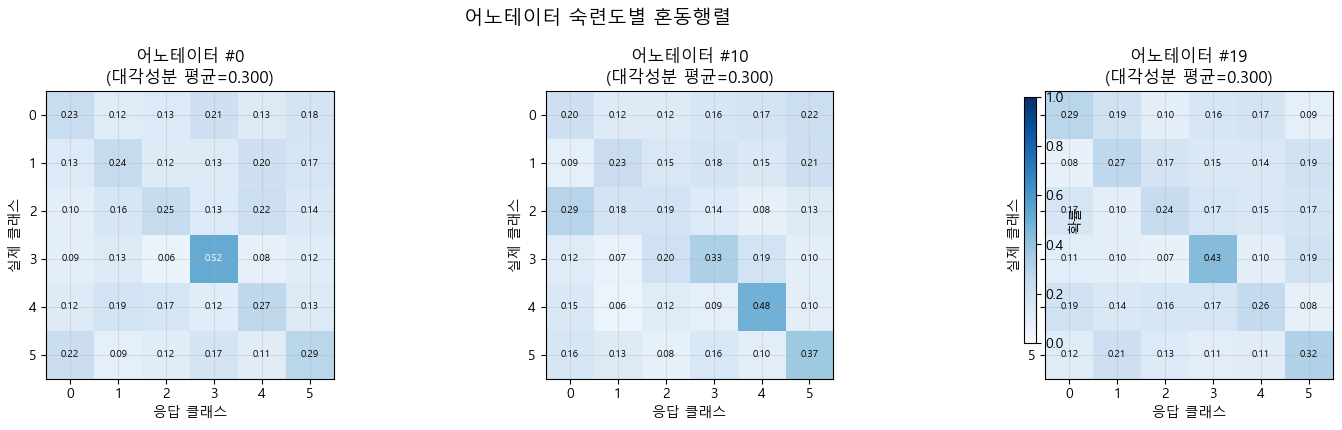

In [7]:
# 혼동행렬 히트맵 시각화
sample_indices = [0, 10, 19]
valid_indices = [i for i in sample_indices if i < num_annotators]

if len(valid_indices) == 0:
    raise ValueError("표시 가능한 어노테이터가 없습니다. sample_indices 또는 num_annotators를 확인하세요.")

if CM_GENERATION_MODE == 'target_accuracy':
    titles = [
        f"어노테이터 #{i}\n(대각성분 평균={np.mean(np.diag(confusion_matrices[i])):.3f})"
        for i in valid_indices
    ]
else:
    titles = [f"어노테이터 #{i}\n(α={diag_alphas[i]})" for i in valid_indices]

fig, axes = plt.subplots(1, len(valid_indices), figsize=(5 * len(valid_indices), 4))
if len(valid_indices) == 1:
    axes = [axes]

for ax, idx, title in zip(axes, valid_indices, titles):
    im = ax.imshow(confusion_matrices[idx], cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("응답 클래스")
    ax.set_ylabel("실제 클래스")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = confusion_matrices[idx][i, j]
            color = 'white' if val > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

fig.colorbar(im, ax=axes, shrink=0.8, label='확률')
fig.suptitle('어노테이터 숙련도별 혼동행렬', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. 샘플 문제 생성 & 응답 시뮬레이션

- **정답 라벨 생성 방식 선택 가능**: 균등 분포 / 사용자 지정 분포
- **응답 시뮬레이션**: 각 어노테이터가 자신의 혼동행렬에 따라 독립적으로 응답
- **MAP 사전확률**: 생성된 샘플의 실제 클래스 분포(경험적 분포)를 사용

$$a_i \sim \text{Categorical}\big(C_i[y_{\text{true}}, \;:\;]\big)$$

정답이 클래스 $m$이면, 어노테이터 $i$는 혼동행렬의 $m$번째 행을 확률분포로 사용하여 응답을 샘플링합니다.

In [8]:
# 공통 파라미터 셀에서 설정한 분포 모드/값을 사용
class_probs = build_class_probs(
    num_classes=NUM_CLASSES,
    class_dist_mode=CLASS_DIST_MODE,
    custom_class_probs=CUSTOM_CLASS_PROBS,
)

# 설정된 분포를 따라 정답 라벨 생성
rng_labels = np.random.default_rng(SEED + 1)
true_labels = rng_labels.choice(NUM_CLASSES, size=NUM_SAMPLES, p=class_probs)

# 생성된 샘플의 경험적 클래스 분포(= MAP prior로 사용)
sample_class_prior = np.bincount(true_labels, minlength=NUM_CLASSES).astype(float)
sample_class_prior /= sample_class_prior.sum()

print(f"클래스 분포 모드: {CLASS_DIST_MODE}")
print("목표 클래스 분포:", np.round(class_probs, 3))
print("생성 샘플 분포:", np.round(sample_class_prior, 3))

print("\n정답 라벨 분포:")
for c in range(NUM_CLASSES):
    cnt = np.sum(true_labels == c)
    print(f"  클래스 {c}: {cnt}개 ({cnt / NUM_SAMPLES * 100:.1f}%)")

# ── 응답 시뮬레이션 ──
all_responses = simulate_responses(confusion_matrices, true_labels, seed=SEED + 2)

print(f"\n응답 행렬 shape: {all_responses.shape}  (샘플 × 어노테이터)")

print("\n처음 5개 샘플의 응답 클래스별 득표 수:")
for s in range(min(5, NUM_SAMPLES)):
    vote_counts = np.bincount(all_responses[s], minlength=NUM_CLASSES)
    print(f"샘플 {s} (실제 라벨={true_labels[s]}):")
    for c in range(NUM_CLASSES):
        print(f"  클래스 {c}: {int(vote_counts[c])}표")

클래스 분포 모드: custom
목표 클래스 분포: [0.35 0.25 0.15 0.1  0.1  0.05]
생성 샘플 분포: [0.356 0.24  0.15  0.104 0.098 0.052]

정답 라벨 분포:
  클래스 0: 1780개 (35.6%)
  클래스 1: 1202개 (24.0%)
  클래스 2: 749개 (15.0%)
  클래스 3: 518개 (10.4%)
  클래스 4: 492개 (9.8%)
  클래스 5: 259개 (5.2%)

응답 행렬 shape: (5000, 20)  (샘플 × 어노테이터)

처음 5개 샘플의 응답 클래스별 득표 수:
샘플 0 (실제 라벨=2):
  클래스 0: 2표
  클래스 1: 3표
  클래스 2: 5표
  클래스 3: 2표
  클래스 4: 2표
  클래스 5: 6표
샘플 1 (실제 라벨=0):
  클래스 0: 9표
  클래스 1: 1표
  클래스 2: 2표
  클래스 3: 3표
  클래스 4: 3표
  클래스 5: 2표
샘플 2 (실제 라벨=0):
  클래스 0: 4표
  클래스 1: 4표
  클래스 2: 2표
  클래스 3: 3표
  클래스 4: 3표
  클래스 5: 4표
샘플 3 (실제 라벨=3):
  클래스 0: 4표
  클래스 1: 2표
  클래스 2: 3표
  클래스 3: 6표
  클래스 4: 3표
  클래스 5: 2표
샘플 4 (실제 라벨=1):
  클래스 0: 2표
  클래스 1: 5표
  클래스 2: 1표
  클래스 3: 4표
  클래스 4: 6표
  클래스 5: 2표


## 4. 베이지안 추론 (Dawid-Skene 모델)

### 4-1. MAP 추정 (Maximum A Posteriori)

사전확률 $P(m)$을 포함하여 **사후확률을 최대화**하는 클래스를 선택:

$$\log P(y{=}m \mid a_1,\dots,a_N) \;\propto\; \log P(m) + \sum_{i=1}^{N} \log C_i[m,\; a_i]$$

$$\hat{y}_{\text{MAP}} = \arg\max_m P(y{=}m \mid a_1,\dots,a_N)$$

### 4-2. MLE 추정 (Maximum Likelihood Estimation)

사전확률을 무시하고 **우도(likelihood)만 최대화**하는 클래스를 선택:

$$\log L(m) = \sum_{i=1}^{N} \log C_i[m,\; a_i]$$

$$\hat{y}_{\text{MLE}} = \arg\max_m L(m)$$

> 이 노트북에서는 MAP의 사전확률을 3번에서 생성된 샘플의 클래스 분포(경험적 분포)로 설정합니다.

In [9]:
def smooth_confusion_matrices(cms, epsilon=1e-12):
    """혼동행렬에 epsilon을 더해 log(0) 방지 후 행별 재정규화."""
    smoothed = []
    for cm in cms:
        s = cm.copy() + epsilon
        s /= s.sum(axis=1, keepdims=True)
        smoothed.append(s)
    return smoothed


def majority_vote_labels(all_responses, num_classes, tie_break='lowest', rng=None):
    """
    다수결 라벨 계산.
    tie_break='lowest'면 동점 시 가장 작은 클래스를 선택한다.
    tie_break='random'이면 동점 클래스 중 무작위 선택한다.
    """
    counts = np.array([np.bincount(row, minlength=num_classes) for row in all_responses], dtype=int)
    max_counts = counts.max(axis=1, keepdims=True)
    winners = counts == max_counts

    if tie_break == 'lowest':
        return winners.argmax(axis=1).astype(int)

    if tie_break == 'random':
        if rng is None:
            rng = np.random.default_rng()
        preds = np.zeros(all_responses.shape[0], dtype=int)
        for s in range(all_responses.shape[0]):
            candidates = np.flatnonzero(winners[s])
            preds[s] = int(rng.choice(candidates))
        return preds

    raise ValueError("tie_break는 'lowest' 또는 'random' 이어야 합니다.")


def compute_confusion_matrix_np(true_labels, pred_labels, num_classes):
    """numpy만으로 confusion matrix 계산."""
    cm = np.zeros((num_classes, num_classes), dtype=int)
    np.add.at(cm, (true_labels.astype(int), pred_labels.astype(int)), 1)
    return cm


def compute_core_metrics(true_labels, pred_labels, num_classes):
    """
    논문용 핵심 지표 계산.
    - overall_accuracy
    - macro_recall
    - minority_class_recall
    """
    cm = compute_confusion_matrix_np(true_labels, pred_labels, num_classes)
    row_sums = cm.sum(axis=1)
    recalls = np.divide(
        np.diag(cm).astype(float),
        np.where(row_sums == 0, 1, row_sums),
    )
    overall_accuracy = float(np.trace(cm) / max(cm.sum(), 1))
    macro_recall = float(np.mean(recalls))

    class_counts = np.bincount(true_labels.astype(int), minlength=num_classes)
    minority_class = int(np.argmin(class_counts))
    minority_recall = float(recalls[minority_class])

    return {
        'overall_accuracy': overall_accuracy,
        'macro_recall': macro_recall,
        'minority_class': minority_class,
        'minority_recall': minority_recall,
        'confusion_matrix': cm,
    }


def _compute_log_likelihood_matrix(all_responses, confusion_matrices, num_classes, epsilon=1e-12):
    """(num_samples, num_classes) 형태의 로그 우도 행렬 계산."""
    smoothed = smooth_confusion_matrices(confusion_matrices, epsilon)
    n_samples = all_responses.shape[0]
    log_like = np.zeros((n_samples, num_classes), dtype=float)

    for i, cm in enumerate(smoothed):
        observed = all_responses[:, i].astype(int)
        log_like += np.log(cm[:, observed].T)

    return log_like


def _compute_log_likelihood_vector(responses, confusion_matrices, num_classes, epsilon=1e-12):
    """단일 샘플에 대한 (num_classes,) 로그 우도 벡터 계산."""
    responses_2d = np.asarray(responses, dtype=int).reshape(1, -1)
    return _compute_log_likelihood_matrix(
        responses_2d,
        confusion_matrices,
        num_classes,
        epsilon=epsilon,
    )[0]


def _normalize_log_scores(log_scores, axis=None):
    """로그 점수를 확률로 정규화."""
    log_scores = np.asarray(log_scores, dtype=float)
    if axis is None:
        return np.exp(log_scores - logsumexp(log_scores))
    return np.exp(log_scores - logsumexp(log_scores, axis=axis, keepdims=True))


def _resolve_prior(prior, num_classes):
    """prior를 검증/정규화하여 (num_classes,) 벡터로 반환."""
    if prior is None:
        prior = np.ones(num_classes, dtype=float) / num_classes
    prior = np.asarray(prior, dtype=float)

    if prior.shape != (num_classes,):
        raise ValueError(f"prior shape은 ({num_classes},) 이어야 합니다.")
    if np.any(prior < 0):
        raise ValueError("prior에는 음수가 포함될 수 없습니다.")

    s = float(prior.sum())
    if s <= 0:
        raise ValueError("prior 합은 0보다 커야 합니다.")

    return prior / s


def compute_threshold_summary(annotator_counts, map_mean, majority_mean, gain=0.05, stable_k=3):
    """
    threshold N 3종 계산:
    1) 다수결 대비 +gain 최초 달성 N
    2) +gain을 연속 stable_k개 N에서 유지하는 첫 N
    3) MAP 최대 성능의 95% 도달 N
    """
    annotator_counts = np.asarray(annotator_counts, dtype=int)
    map_mean = np.asarray(map_mean, dtype=float)
    majority_mean = np.asarray(majority_mean, dtype=float)

    gain_series = map_mean - majority_mean

    first_gain_n = None
    for n, g in zip(annotator_counts, gain_series):
        if g >= gain:
            first_gain_n = int(n)
            break

    stable_gain_n = None
    if stable_k <= 1:
        stable_gain_n = first_gain_n
    else:
        for i in range(0, len(annotator_counts) - stable_k + 1):
            if np.all(gain_series[i:i + stable_k] >= gain):
                stable_gain_n = int(annotator_counts[i])
                break

    max95_target = 0.95 * float(np.max(map_mean))
    max95_n = None
    for n, v in zip(annotator_counts, map_mean):
        if v >= max95_target:
            max95_n = int(n)
            break

    return {
        'first_gain_n': first_gain_n,
        'stable_gain_n': stable_gain_n,
        'max95_n': max95_n,
        'gain_series': gain_series,
        'max95_target': max95_target,
    }


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [MLE] Maximum Likelihood Estimation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def predict_class_mle(responses, confusion_matrices, num_classes, epsilon=1e-12):
    """
    [MLE] 단일 샘플에 대해 MLE 추정 수행.
    사전확률 없이 우도(likelihood)만 최대화.

    log L(m) = sum_i log C_i[m, a_i]

    Returns:
        (predicted_class, normalized_likelihoods)
    """
    log_likelihood = _compute_log_likelihood_vector(
        responses,
        confusion_matrices,
        num_classes,
        epsilon=epsilon,
    )
    likelihoods = _normalize_log_scores(log_likelihood)

    return int(np.argmax(likelihoods)), likelihoods


def predict_dataset_mle(all_responses, confusion_matrices, num_classes, epsilon=1e-12):
    """
    [MLE] 전체 데이터셋에 대해 MLE 추론 일괄 수행.

    Returns:
        (predictions, all_likelihoods)  - shape (N,), (N, K)
    """
    log_like = _compute_log_likelihood_matrix(all_responses, confusion_matrices, num_classes, epsilon)
    likelihoods = _normalize_log_scores(log_like, axis=1)

    predictions = np.argmax(likelihoods, axis=1).astype(int)
    return predictions, likelihoods


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  [MAP] Maximum A Posteriori 추정
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def predict_class_map(responses, confusion_matrices, num_classes, prior=None, epsilon=1e-12):
    """
    [MAP] 단일 샘플에 대해 MAP 추정 수행.
    MLE 로그우도에 log prior를 더해 사후확률 최대화.

    Returns:
        (predicted_class, posterior_probs)
    """
    prior = _resolve_prior(prior, num_classes)

    log_likelihood = _compute_log_likelihood_vector(
        responses,
        confusion_matrices,
        num_classes,
        epsilon=epsilon,
    )
    log_post = log_likelihood + np.log(prior + 1e-300)
    posterior = _normalize_log_scores(log_post)

    return int(np.argmax(posterior)), posterior


def predict_dataset_map(all_responses, confusion_matrices, num_classes, prior=None, epsilon=1e-12):
    """
    [MAP] 전체 데이터셋에 대해 MAP 추론 일괄 수행.
    MLE 로그우도 행렬에 클래스별 log prior를 더해 사후확률 계산.

    Returns:
        (predictions, all_posteriors)  - shape (N,), (N, K)
    """
    prior = _resolve_prior(prior, num_classes)

    log_like = _compute_log_likelihood_matrix(all_responses, confusion_matrices, num_classes, epsilon)
    log_post = log_like + np.log(prior + 1e-300)
    posterior = _normalize_log_scores(log_post, axis=1)

    predictions = np.argmax(posterior, axis=1).astype(int)
    return predictions, posterior


def evaluate_subset_once(
    all_responses,
    confusion_matrices,
    subset_idx,
    true_labels,
    num_classes,
    prior,
    tie_break='lowest',
):
    """어노테이터 부분집합 1회 평가 결과 반환."""
    sub_resp = all_responses[:, subset_idx]
    sub_cms = [confusion_matrices[i] for i in subset_idx]

    preds_map, _ = predict_dataset_map(sub_resp, sub_cms, num_classes, prior=prior)
    preds_mle, _ = predict_dataset_mle(sub_resp, sub_cms, num_classes)
    preds_maj = majority_vote_labels(sub_resp, num_classes, tie_break=tie_break)

    return {
        'map_acc': float(np.mean(preds_map == true_labels)),
        'mle_acc': float(np.mean(preds_mle == true_labels)),
        'majority_acc': float(np.mean(preds_maj == true_labels)),
        'preds_map': preds_map,
        'preds_mle': preds_mle,
        'preds_majority': preds_maj,
    }


def evaluate_n_curve_multiseed(
    confusion_matrices,
    num_classes,
    num_samples,
    class_probs,
    seed_list,
    subset_repeats_small_n=10,
    subset_repeats_large_n=3,
    small_n_cutoff=10,
    tie_break='lowest',
    threshold_gain=0.05,
    threshold_stable_k=3,
):
    """
    N-curve 실험:
    - 다중 시드
    - n별 무작위 부분집합 반복
    - mean±std 및 threshold 요약 반환
    """
    num_annotators = len(confusion_matrices)
    annotator_counts = np.arange(1, num_annotators + 1, dtype=int)

    map_by_seed = []
    mle_by_seed = []
    majority_by_seed = []

    for seed in seed_list:
        rng_labels = np.random.default_rng(seed + 1)
        true_labels = rng_labels.choice(num_classes, size=num_samples, p=class_probs)

        prior = np.bincount(true_labels, minlength=num_classes).astype(float)
        prior /= prior.sum()

        all_responses = simulate_responses(confusion_matrices, true_labels, seed=seed + 2)
        rng_subset = np.random.default_rng(seed + 20000)

        map_curve = np.zeros(num_annotators, dtype=float)
        mle_curve = np.zeros(num_annotators, dtype=float)
        maj_curve = np.zeros(num_annotators, dtype=float)

        for idx, n in enumerate(annotator_counts):
            if n == num_annotators:
                repeats = 1
            elif n <= small_n_cutoff:
                repeats = int(subset_repeats_small_n)
            else:
                repeats = int(subset_repeats_large_n)

            map_runs, mle_runs, maj_runs = [], [], []
            for _ in range(repeats):
                if n == num_annotators:
                    subset_idx = np.arange(num_annotators, dtype=int)
                else:
                    subset_idx = rng_subset.choice(num_annotators, size=n, replace=False)

                result = evaluate_subset_once(
                    all_responses=all_responses,
                    confusion_matrices=confusion_matrices,
                    subset_idx=subset_idx,
                    true_labels=true_labels,
                    num_classes=num_classes,
                    prior=prior,
                    tie_break=tie_break,
                )
                map_runs.append(result['map_acc'])
                mle_runs.append(result['mle_acc'])
                maj_runs.append(result['majority_acc'])

            map_curve[idx] = float(np.mean(map_runs))
            mle_curve[idx] = float(np.mean(mle_runs))
            maj_curve[idx] = float(np.mean(maj_runs))

        map_by_seed.append(map_curve)
        mle_by_seed.append(mle_curve)
        majority_by_seed.append(maj_curve)

    map_by_seed = np.array(map_by_seed, dtype=float)
    mle_by_seed = np.array(mle_by_seed, dtype=float)
    majority_by_seed = np.array(majority_by_seed, dtype=float)

    map_mean = map_by_seed.mean(axis=0)
    mle_mean = mle_by_seed.mean(axis=0)
    maj_mean = majority_by_seed.mean(axis=0)

    map_std = map_by_seed.std(axis=0, ddof=0)
    mle_std = mle_by_seed.std(axis=0, ddof=0)
    maj_std = majority_by_seed.std(axis=0, ddof=0)

    threshold = compute_threshold_summary(
        annotator_counts=annotator_counts,
        map_mean=map_mean,
        majority_mean=maj_mean,
        gain=threshold_gain,
        stable_k=threshold_stable_k,
    )

    return {
        'annotator_counts': annotator_counts,
        'map_mean': map_mean,
        'map_std': map_std,
        'mle_mean': mle_mean,
        'mle_std': mle_std,
        'majority_mean': maj_mean,
        'majority_std': maj_std,
        'threshold': threshold,
        'map_by_seed': map_by_seed,
        'mle_by_seed': mle_by_seed,
        'majority_by_seed': majority_by_seed,
    }


# 하위 호환: 기존 이름도 유지 (MAP 기본)
predict_class = predict_class_map
predict_dataset = predict_dataset_map

print("추론/평가 함수 정의 완료 ✓  (MAP + MLE + 프로토콜 유틸)")

추론/평가 함수 정의 완료 ✓  (MAP + MLE + 프로토콜 유틸)


## 5. 추론 실행 & 다수결 비교

In [10]:
# -- MAP 추론 (3번에서 생성한 샘플 클래스 분포 prior 사용) --
predictions_map, all_posteriors = predict_dataset_map(
    all_responses,
    confusion_matrices,
    NUM_CLASSES,
    prior=sample_class_prior,
)
map_accuracy = float(np.mean(predictions_map == true_labels))

# -- MLE 추론 --
predictions_mle, all_likelihoods = predict_dataset_mle(
    all_responses, confusion_matrices, NUM_CLASSES
)
mle_accuracy = float(np.mean(predictions_mle == true_labels))

# -- 다수결 투표 (프로토콜 고정 tie-break 적용) --
majority_votes = majority_vote_labels(
    all_responses,
    NUM_CLASSES,
    tie_break=MAJORITY_TIE_BREAK,
)
majority_accuracy = float(np.mean(majority_votes == true_labels))

# -- 랜덤 기준선 --
random_baseline = 1.0 / NUM_CLASSES

# -- 결과 비교 --
print("MAP prior (샘플 분포):", np.round(sample_class_prior, 3))
print(f"다수결 tie-break 규칙: {MAJORITY_TIE_BREAK}")

# 투표/추론에 사용된 어노테이터 정확도 및 참여 인원 출력
if CM_GENERATION_MODE == 'target_accuracy':
    print("\n참여 어노테이터 구성 (설정 정확도 기준):")
    for label, (count, acc) in TARGET_ANNOTATOR_CONFIG.items():
        if int(count) > 0:
            role = str(label)
            if "(acc=" in role:
                role = role.split("(acc=")[0].strip()
            print(f"  정확도={float(acc):.3f}: {int(count)}명 ({role})")
else:
    annotator_accs = np.array([float(np.mean(np.diag(cm))) for cm in confusion_matrices], dtype=float)
    acc_values, acc_counts = np.unique(np.round(annotator_accs, 3), return_counts=True)
    sort_idx = np.argsort(-acc_values)

    print("\n참여 어노테이터 구성 (평균 대각성분 기준):")
    for acc, cnt in zip(acc_values[sort_idx], acc_counts[sort_idx]):
        print(f"  정확도≈{acc:.3f}: {int(cnt)}명")

print(f"\n{'방법':<22} {'정확도':>10}")
print(f"{'-' * 35}")
print(f"{'랜덤 기준선':<22} {random_baseline:>9.2%}")
print(f"{'다수결 투표':<22} {majority_accuracy:>9.2%}")
print(f"{'MLE 추론':<22} {mle_accuracy:>9.2%}")
print(f"{'MAP 추론 (DS)':<22} {map_accuracy:>9.2%}")

best = max(map_accuracy, mle_accuracy, majority_accuracy)
if best == map_accuracy:
    print("\n-> MAP 추론이 가장 높은 정확도 달성")
elif best == mle_accuracy:
    print("\n-> MLE 추론이 가장 높은 정확도 달성")
else:
    print("\n-> 다수결 투표가 가장 높은 정확도 달성")

# 하위 호환: 이후 시각화 셀에서 사용할 변수 유지
predictions = predictions_map
bayes_accuracy = map_accuracy

MAP prior (샘플 분포): [0.356 0.24  0.15  0.104 0.098 0.052]
다수결 tie-break 규칙: lowest

참여 어노테이터 구성 (설정 정확도 기준):
  정확도=0.300: 20명 (중급자 )

방법                            정확도
-----------------------------------
랜덤 기준선                    16.67%
다수결 투표                    67.48%
MLE 추론                    76.82%
MAP 추론 (DS)               79.90%

-> MAP 추론이 가장 높은 정확도 달성


## 6. 집단 대각 평균 수준별 오류 집중도 스윕

프로토콜(지표/시드/부분집합 평가)을 유지한 채,
라벨러 집단의 평균 대각 성분(품질)을 아래 5개 수준으로 바꾸어 비교합니다.

- 대각 평균 후보: 10%, 30%, 50%, 70%, 90%
- x축: 오류 집중도 `focus_ratio`
- y축: 다수결 대비 MAP 이점 (`MAP - Majority`, %p)
- 출력: 다중 곡선(색상별) + 수치 요약표

선택된 폰트: Malgun Gothic


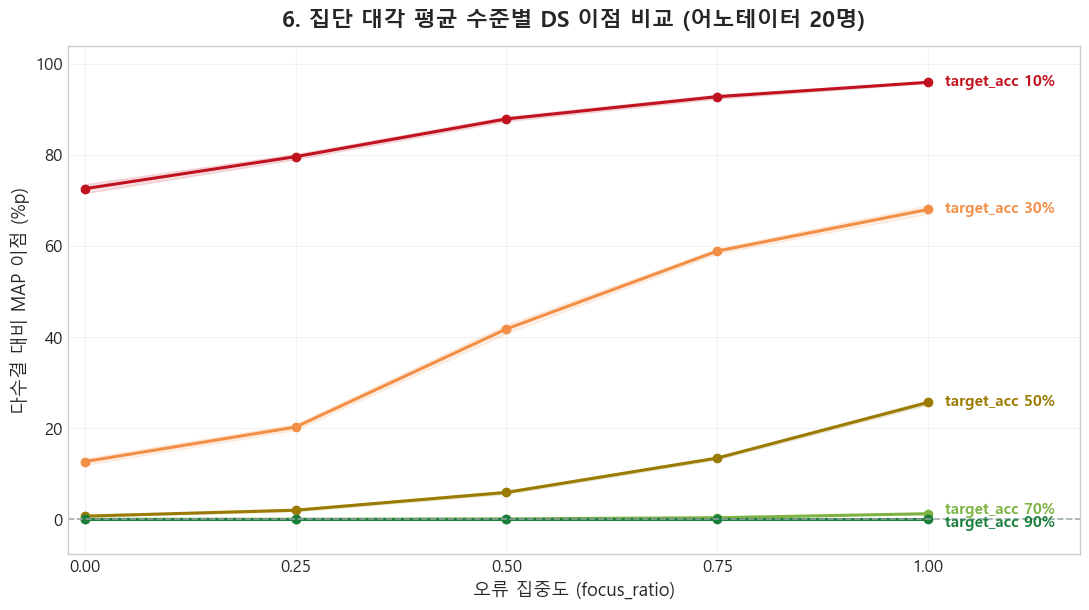

[실험 6 결과 표: 대각 평균 수준별 오류 집중도 스윕 | 속도 우선 버전]
설정: seeds=[42, 52, 62, 72, 82, 92, 102, 112, 122, 132], pairs=[(0, 1), (0, 3)], tie_break=lowest, parallel=True, backend=thread, workers=10
  target   actual   focus       MAP(mean±std)       Maj(mean±std)       Gap(mean±std)
--------------------------------------------------------------------------------------------------------------
    0.10    0.100    0.00  78.69%±0.76%     6.12%±0.29%   +72.57%±0.99%  
    0.10    0.100    0.25  83.07%±0.64%     3.47%±0.23%   +79.60%±0.57%  
    0.10    0.100    0.50  89.05%±0.49%     1.16%±0.09%   +87.89%±0.51%  
    0.10    0.100    0.75  93.27%±0.41%     0.50%±0.08%   +92.77%±0.45%  
    0.10    0.100    1.00  96.41%±0.21%     0.48%±0.11%   +95.93%±0.18%  
    0.30    0.300    0.00  80.22%±0.66%    67.56%±0.47%   +12.67%±0.73%  
    0.30    0.300    0.25  79.01%±0.55%    58.77%±0.64%   +20.25%±0.67%  
    0.30    0.300    0.50  86.79%±0.55%    45.01%±0.57%   +41.78%±0.96%  
    0.30    0.300    0.75  

In [11]:
# %% [markdown]
# ## 6. 집단 대각 평균 수준별 오류 집중도 스윕 (속도 우선 버전)
#
# 변경 내용
# 1) simulate_responses 벡터화
# 2) cms_fr별 log-cms 캐시
# 3) majority_vote_labels(lowest) 벡터화
# 4) seed 축 병렬화 옵션 추가
#
# 주의:
# - 기존과 "완전히 동일한 숫자"는 보장하지 않음
# - 특히 simulate_responses 벡터화 때문에 같은 seed여도 수치가 조금 달라질 수 있음
# - notebook/Windows 환경에서는 process 병렬화가 불안정할 수 있어 기본은 thread 권장

# %%
import os
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

required_symbols = [
    'generate_annotator_confusion_matrices',
    'build_class_probs',
]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise ValueError(
        '먼저 섹션 0~5 관련 코드 셀을 실행해주세요. 누락 심볼: ' + ', '.join(missing_symbols)
    )

if MAJORITY_TIE_BREAK != 'lowest':
    raise ValueError(
        "이 고속 버전은 현재 MAJORITY_TIE_BREAK='lowest'일 때만 작성했습니다."
    )

# =========================
# 병렬화 설정
# =========================
USE_PARALLEL = True
PARALLEL_BACKEND = 'thread'   # 'thread' 권장 / 환경 괜찮으면 'process' 가능
MAX_WORKERS = min(len(SEED_LIST), max(1, (os.cpu_count() or 1) - 1))

if PARALLEL_BACKEND not in ('thread', 'process'):
    raise ValueError("PARALLEL_BACKEND는 'thread' 또는 'process' 이어야 합니다.")


# =========================
# 로컬 유틸
# =========================
def smooth_confusion_matrices_local(cms, epsilon=1e-12):
    smoothed = []
    for cm in cms:
        s = np.asarray(cm, dtype=float).copy() + epsilon
        s /= s.sum(axis=1, keepdims=True)
        smoothed.append(s)
    return smoothed


def _normalize_log_scores_local(log_scores, axis=None):
    log_scores = np.asarray(log_scores, dtype=float)
    if axis is None:
        return np.exp(log_scores - logsumexp(log_scores))
    return np.exp(log_scores - logsumexp(log_scores, axis=axis, keepdims=True))


def _resolve_prior_local(prior, num_classes):
    if prior is None:
        prior = np.ones(num_classes, dtype=float) / num_classes
    prior = np.asarray(prior, dtype=float)

    if prior.shape != (num_classes,):
        raise ValueError(f"prior shape은 ({num_classes},) 이어야 합니다.")
    if np.any(prior < 0):
        raise ValueError("prior에는 음수가 포함될 수 없습니다.")

    s = float(prior.sum())
    if s <= 0:
        raise ValueError("prior 합은 0보다 커야 합니다.")

    return prior / s


def apply_focus_sweep_pattern(cm, confusable_pairs, focus_ratio):
    """
    대각 성분은 유지한 채, 오프대각 오류 질량을
    - focus_ratio=0.0: 기존 오프대각 분포 유지
    - focus_ratio=1.0: 지정 혼동쌍으로 최대 집중
    으로 연속 보간한다.
    """
    if not (0.0 <= float(focus_ratio) <= 1.0):
        raise ValueError('focus_ratio는 [0, 1] 범위여야 합니다.')

    base = np.asarray(cm, dtype=float)
    k = base.shape[0]
    out = base.copy()

    for src in range(k):
        diag = float(base[src, src])
        off_sum = max(0.0, 1.0 - diag)

        row = np.zeros(k, dtype=float)
        row[src] = diag

        if off_sum <= 0.0:
            out[src] = row
            continue

        off_idx = [j for j in range(k) if j != src]

        w_base = base[src, off_idx].astype(float)
        s_base = float(w_base.sum())
        if s_base <= 0:
            w_base = np.ones(len(off_idx), dtype=float) / len(off_idx)
        else:
            w_base = w_base / s_base

        pair_targets = []
        for a, b in confusable_pairs:
            a = int(a)
            b = int(b)
            if src == a:
                pair_targets.append(b)
            elif src == b:
                pair_targets.append(a)

        w_focus = np.zeros(len(off_idx), dtype=float)
        for idx, tgt in enumerate(off_idx):
            if tgt in pair_targets:
                w_focus[idx] = 1.0

        if float(w_focus.sum()) <= 0:
            w_focus = w_base.copy()
        else:
            w_focus = w_focus / float(w_focus.sum())

        w_mix = (1.0 - float(focus_ratio)) * w_base + float(focus_ratio) * w_focus
        w_mix = w_mix / float(w_mix.sum())

        row[off_idx] = off_sum * w_mix
        out[src] = row

    out = np.clip(out, 0.0, 1.0)
    out = out / out.sum(axis=1, keepdims=True)
    return out


def mean_std_np(values):
    arr = np.asarray(values, dtype=float)
    return float(arr.mean()), float(arr.std(ddof=0))


def precompute_log_cms(confusion_matrices, epsilon=1e-12):
    """
    혼동행렬 리스트 -> smoothed log-cms 배열
    shape: (A, K, K)
    """
    smoothed = smooth_confusion_matrices_local(confusion_matrices, epsilon)
    return np.stack([np.log(cm) for cm in smoothed], axis=0)


def predict_dataset_map_from_logcms(all_responses, log_cms, prior):
    """
    미리 계산된 log_cms를 사용해 MAP 추론 수행.
    """
    num_samples = all_responses.shape[0]
    num_classes = log_cms.shape[1]

    prior = _resolve_prior_local(prior, num_classes)
    log_like = np.zeros((num_samples, num_classes), dtype=float)

    for i in range(log_cms.shape[0]):
        observed = all_responses[:, i].astype(int)
        # shape: (num_samples, num_classes)
        log_like += log_cms[i, :, observed]

    log_post = log_like + np.log(prior + 1e-300)
    posterior = _normalize_log_scores_local(log_post, axis=1)
    preds = np.argmax(posterior, axis=1).astype(int)
    return preds, posterior


_eye_cache = {}

def majority_vote_labels_fast_lowest(all_responses, num_classes):
    """
    tie_break='lowest' 전용 빠른 다수결
    """
    eye = _eye_cache.get(num_classes)
    if eye is None:
        eye = np.eye(num_classes, dtype=np.int16)
        _eye_cache[num_classes] = eye

    counts = eye[all_responses].sum(axis=1)
    return counts.argmax(axis=1).astype(int)


def simulate_responses_vectorized(confusion_matrices, true_labels, seed=None):
    """
    속도 우선 버전 응답 시뮬레이션.
    기존과 정확히 동일한 난수 소비 순서는 아니므로 수치가 조금 달라질 수 있음.
    """
    rng = np.random.default_rng(seed)
    true_labels = np.asarray(true_labels, dtype=int)

    num_samples = true_labels.shape[0]
    num_ann = len(confusion_matrices)
    responses = np.empty((num_samples, num_ann), dtype=np.int16)

    for i, cm in enumerate(confusion_matrices):
        probs = np.asarray(cm, dtype=float)[true_labels]      # (N, K)
        cdf = np.cumsum(probs, axis=1)
        cdf[:, -1] = 1.0                                     # 수치 안정성
        u = rng.random(num_samples)[:, None]                 # (N, 1)
        responses[:, i] = np.argmax(u <= cdf, axis=1)

    return responses


def evaluate_one_seed_sec6(args):
    """
    seed 하나에 대한 MAP / Majority 정확도 계산
    병렬 map용으로 args tuple 받음
    """
    (
        seed,
        target_key,
        fr,
        class_probs_local,
        cms_fr,
        log_cms_fr,
        num_classes,
        num_samples,
    ) = args

    seed_offset = int(round(target_key * 1000)) * 10000 + int(round(fr * 1000))

    rng_labels_case = np.random.default_rng(int(seed + 81000 + seed_offset))
    labels_case = rng_labels_case.choice(num_classes, size=num_samples, p=class_probs_local)

    prior_case = np.bincount(labels_case, minlength=num_classes).astype(float)
    prior_case /= prior_case.sum()

    responses_case = simulate_responses_vectorized(
        cms_fr,
        labels_case,
        seed=int(seed + 82000 + seed_offset),
    )

    preds_map, _ = predict_dataset_map_from_logcms(
        responses_case,
        log_cms_fr,
        prior_case,
    )

    preds_maj = majority_vote_labels_fast_lowest(
        responses_case,
        num_classes,
    )

    map_acc = float(np.mean(preds_map == labels_case))
    maj_acc = float(np.mean(preds_maj == labels_case))
    return map_acc, maj_acc


# =========================
# 실험 설정
# =========================
N_ANN_SWEEP = 20
diag_mean_targets = np.array([0.10, 0.30, 0.50, 0.70, 0.90], dtype=float)
focus_values = np.array([0.00, 0.25, 0.50, 0.75, 1.00], dtype=float)
confusable_pairs = [(0, 1), (0, 3)]
seed_values = list(SEED_LIST)

if 'class_probs' in globals():
    class_probs_local = np.asarray(class_probs, dtype=float)
else:
    class_probs_local = build_class_probs(
        num_classes=NUM_CLASSES,
        class_dist_mode=CLASS_DIST_MODE,
        custom_class_probs=CUSTOM_CLASS_PROBS,
    )
class_probs_local = class_probs_local / class_probs_local.sum()


# =========================
# target별 base confusion matrix 생성
# =========================
cms_by_target_sec6 = {}
actual_diag_by_target_sec6 = {}

for target_diag in diag_mean_targets:
    target_key = float(target_diag)
    target_cfg = {
        f'균질 그룹 ({target_key:.0%})': (int(N_ANN_SWEEP), target_key),
    }

    cms_target, _, n_ann_target = generate_annotator_confusion_matrices(
        num_classes=NUM_CLASSES,
        annotator_config=ANNOTATOR_CONFIG,
        seed=int(SEED + 51000 + round(target_key * 1000)),
        cm_generation_mode='target_accuracy',
        off_alpha=OFF_ALPHA,
        target_acc=target_key,
        target_annotator_config=target_cfg,
        accuracy_mode='uniform_weighted',
        target_base_diag_alpha=TARGET_BASE_DIAG_ALPHA,
        diag_spread=DIAG_SPREAD,
        target_offdiag_alpha=TARGET_OFFDIAG_ALPHA,
    )

    if int(n_ann_target) != int(N_ANN_SWEEP):
        raise ValueError(
            f'조건 target={target_key:.2f}에서 어노테이터 수가 {N_ANN_SWEEP}명이 아닙니다: {n_ann_target}'
        )

    actual_diag = float(np.mean([np.mean(np.diag(cm)) for cm in cms_target]))
    cms_by_target_sec6[target_key] = cms_target
    actual_diag_by_target_sec6[target_key] = actual_diag


# =========================
# 본 실험
# =========================
diag_sweep_results_sec6 = []
diag_sweep_by_target_sec6 = {}

for target_diag in diag_mean_targets:
    target_key = float(target_diag)
    base_cms = cms_by_target_sec6[target_key]
    rows = []

    for fr in focus_values:
        fr = float(fr)

        cms_fr = [
            apply_focus_sweep_pattern(cm.copy(), confusable_pairs, focus_ratio=fr)
            for cm in base_cms
        ]

        log_cms_fr = precompute_log_cms(cms_fr)
        actual_diag_focus = float(np.mean([np.mean(np.diag(cm)) for cm in cms_fr]))

        worker_args = [
            (
                seed,
                target_key,
                fr,
                class_probs_local,
                cms_fr,
                log_cms_fr,
                NUM_CLASSES,
                NUM_SAMPLES,
            )
            for seed in seed_values
        ]

        if USE_PARALLEL and len(worker_args) > 1:
            executor_cls = ThreadPoolExecutor if PARALLEL_BACKEND == 'thread' else ProcessPoolExecutor
            with executor_cls(max_workers=MAX_WORKERS) as ex:
                seed_results = list(ex.map(evaluate_one_seed_sec6, worker_args))
        else:
            seed_results = [evaluate_one_seed_sec6(args) for args in worker_args]

        map_seed_means = [r[0] for r in seed_results]
        maj_seed_means = [r[1] for r in seed_results]

        map_mu, map_sd = mean_std_np(map_seed_means)
        maj_mu, maj_sd = mean_std_np(maj_seed_means)

        gap_seed = np.asarray(map_seed_means, dtype=float) - np.asarray(maj_seed_means, dtype=float)
        gap_mu, gap_sd = mean_std_np(gap_seed)

        row = {
            'target_diag': target_key,
            'actual_diag_base': float(actual_diag_by_target_sec6[target_key]),
            'actual_diag_focus': actual_diag_focus,
            'focus_ratio': fr,
            'map_mean': float(map_mu),
            'map_std': float(map_sd),
            'maj_mean': float(maj_mu),
            'maj_std': float(maj_sd),
            'gap_mean': float(gap_mu),
            'gap_std': float(gap_sd),
        }

        rows.append(row)
        diag_sweep_results_sec6.append(row)

    diag_sweep_by_target_sec6[target_key] = rows


# =========================
# 시각화
# =========================
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager

# 사용 가능한 한글 폰트 찾기
available_fonts = {f.name for f in font_manager.fontManager.ttflist}

for font_name in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR']:
    if font_name in available_fonts:
        KOREAN_FONT = font_name
        break
else:
    KOREAN_FONT = None

print("선택된 폰트:", KOREAN_FONT)

if KOREAN_FONT is not None:
    matplotlib.rcParams['font.family'] = KOREAN_FONT
    matplotlib.rcParams['axes.unicode_minus'] = False
else:
    print("한글 폰트를 찾지 못했습니다.")

with plt.style.context('seaborn-v0_8-whitegrid'):
    plt.rcParams['font.family'] = KOREAN_FONT
    plt.rcParams['axes.unicode_minus'] = False

    fig, ax = plt.subplots(figsize=(11.0, 6.2))
    colors = np.array(['#c1121f', '#f28e45', '#9a7a00', '#7cb342', '#1b7f3b'])

    label_y_offsets = {
        0.10: 0.0,
        0.30: 0.0,
        0.50: 0.0,
        0.70: 0.8,
        0.90: -0.8,
    }

    for color, target_diag in zip(colors, diag_mean_targets):
        rows = sorted(diag_sweep_by_target_sec6[float(target_diag)], key=lambda x: x['focus_ratio'])
        xs = np.array([r['focus_ratio'] for r in rows], dtype=float)
        ys = np.array([r['gap_mean'] for r in rows], dtype=float) * 100.0
        ys_std = np.array([r['gap_std'] for r in rows], dtype=float) * 100.0

        ax.plot(
            xs,
            ys,
            'o-',
            lw=2.2,
            ms=6,
            color=color,
        )
        ax.fill_between(xs, ys - ys_std, ys + ys_std, color=color, alpha=0.13)

        # 각 선의 마지막 점 오른쪽에 직접 라벨 표시 (겹침 방지 오프셋 포함)
        offset_y = label_y_offsets.get(round(float(target_diag), 2), 0.0)
        ax.text(
            xs[-1] + 0.02,
            ys[-1] + offset_y,
            f'target_acc {target_diag:.0%}',
            color=color,
            fontsize=11,
            va='center',
            ha='left',
            fontweight='bold',
        )

    ax.axhline(0.0, color='#95a5a6', linestyle='--', linewidth=1.2, alpha=0.9)
    ax.set_xticks(focus_values)
    ax.set_xticklabels([f'{x:.2f}' for x in focus_values], fontsize=12)

    all_gap = np.array([r['gap_mean'] for r in diag_sweep_results_sec6], dtype=float) * 100.0
    all_gap_std = np.array([r['gap_std'] for r in diag_sweep_results_sec6], dtype=float) * 100.0
    y_low = float(np.min(all_gap - all_gap_std))
    y_high = float(np.max(all_gap + all_gap_std))
    y_pad = max(1.5, 0.08 * (y_high - y_low + 1e-9))
    ax.set_ylim(min(-1.0, y_low - y_pad), y_high + y_pad)
    ax.set_xlim(float(np.min(focus_values)) - 0.02, float(np.max(focus_values)) + 0.18)

    ax.set_xlabel('오류 집중도 (focus_ratio)', fontsize=13)
    ax.set_ylabel('다수결 대비 MAP 이점 (%p)', fontsize=13)
    ax.set_title(
        f'6. 집단 대각 평균 수준별 DS 이점 비교 (어노테이터 {N_ANN_SWEEP}명)',
        fontsize=16,
        fontweight='bold',
        pad=14,
    )
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


# =========================
# 표 출력
# =========================
print('[실험 6 결과 표: 대각 평균 수준별 오류 집중도 스윕 | 속도 우선 버전]')
print(
    f'설정: seeds={seed_values}, pairs={confusable_pairs}, '
    f'tie_break={MAJORITY_TIE_BREAK}, parallel={USE_PARALLEL}, '
    f'backend={PARALLEL_BACKEND}, workers={MAX_WORKERS}'
)
print(
    f"{'target':>8} {'actual':>8} {'focus':>7} "
    f"{'MAP(mean±std)':>19} {'Maj(mean±std)':>19} {'Gap(mean±std)':>19}"
)
print('-' * 110)

for target_diag in diag_mean_targets:
    rows = sorted(diag_sweep_by_target_sec6[float(target_diag)], key=lambda x: x['focus_ratio'])
    for r in rows:
        print(
            f"{r['target_diag']:>8.2f} "
            f"{r['actual_diag_focus']:>8.3f} "
            f"{r['focus_ratio']:>7.2f} "
            f"{r['map_mean']:>7.2%}±{r['map_std']:<7.2%} "
            f"{r['maj_mean']:>7.2%}±{r['maj_std']:<7.2%} "
            f"{r['gap_mean']:>+7.2%}±{r['gap_std']:<7.2%}"
        )

print('\n[focus_ratio=1.00 품질별 MAP-다수결 이점]')
for target_diag in diag_mean_targets:
    rows = diag_sweep_by_target_sec6[float(target_diag)]
    row_f1 = min(rows, key=lambda x: abs(x['focus_ratio'] - 1.0))
    print(
        f"target={target_diag:.0%} (actual≈{row_f1['actual_diag_focus']:.1%}) -> "
        f"MAP-Majority={row_f1['gap_mean']:+.2%}"
    )

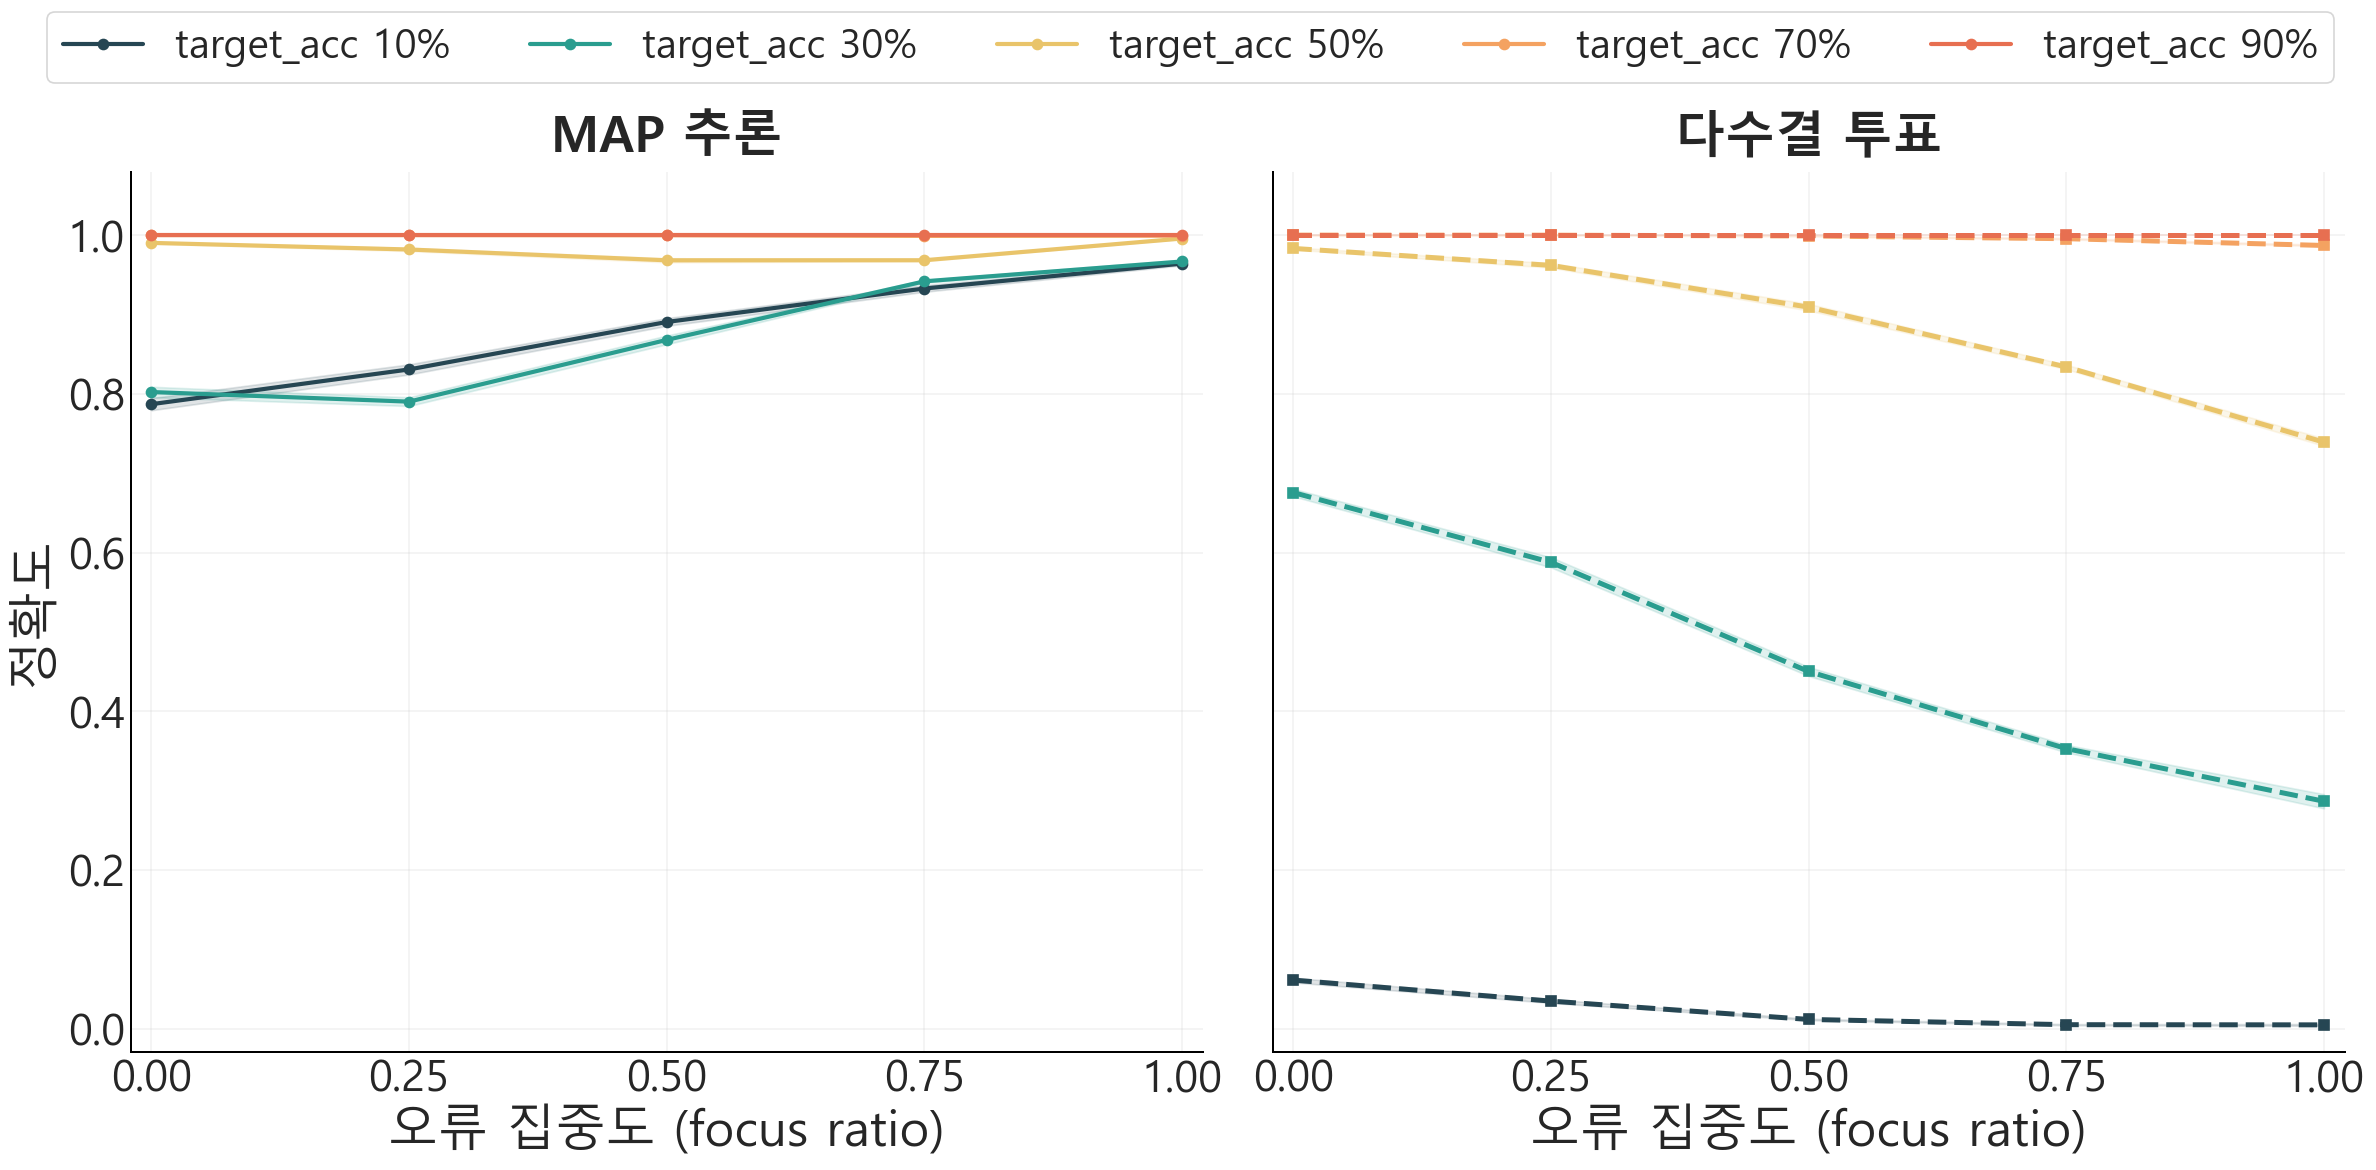

In [86]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 17번 셀에서 계산된 결과를 사용해 MAP/다수결 정확도를 각각 시각화
required_vars = ['diag_mean_targets', 'diag_sweep_by_target_sec6', 'focus_values', 'N_ANN_SWEEP']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError('먼저 17번 셀을 실행해주세요. 누락 변수: ' + ', '.join(missing))

# 한글 폰트 설정 (Windows 경로 우선)
font_candidates = [
    ('Malgun Gothic', r'C:\Windows\Fonts\malgun.ttf'),
    ('NanumGothic', r'C:\Windows\Fonts\NanumGothic.ttf'),
    ('Noto Sans CJK KR', r'C:\Windows\Fonts\NotoSansCJK-Regular.ttc'),
]

font_name = None
for name, fpath in font_candidates:
    if os.path.exists(fpath):
        try:
            font_manager.fontManager.addfont(fpath)
            font_name = name
            break
        except Exception:
            pass

if font_name is None:
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    for name, _ in font_candidates:
        if name in available_fonts:
            font_name = name
            break

if font_name is None:
    font_name = 'DejaVu Sans'

matplotlib.rcParams['font.family'] = font_name
matplotlib.rcParams['axes.unicode_minus'] = False

with plt.style.context('seaborn-v0_8-whitegrid'):
    plt.rcParams['font.family'] = font_name
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(20.0, 10.0), sharex=True, sharey=True, dpi=120)
    colors = np.array(['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51'])

    y_all = []
    for target_diag in diag_mean_targets:
        rows = sorted(diag_sweep_by_target_sec6[float(target_diag)], key=lambda x: x['focus_ratio'])
        for r in rows:
            y_all.extend([
                r['map_mean'] - r['map_std'],
                r['map_mean'] + r['map_std'],
                r['maj_mean'] - r['maj_std'],
                r['maj_mean'] + r['maj_std'],
            ])

    y_min = float(np.min(y_all))
    y_max = float(np.max(y_all))
    y_pad = max(0.01, 0.08 * (y_max - y_min + 1e-9))
    y_upper = min(1.08, y_max + y_pad + 0.02)

    for color, target_diag in zip(colors, diag_mean_targets):
        rows = sorted(diag_sweep_by_target_sec6[float(target_diag)], key=lambda x: x['focus_ratio'])
        xs = np.array([r['focus_ratio'] for r in rows], dtype=float)

        map_mu = np.array([r['map_mean'] for r in rows], dtype=float)
        map_sd = np.array([r['map_std'] for r in rows], dtype=float)
        maj_mu = np.array([r['maj_mean'] for r in rows], dtype=float)
        maj_sd = np.array([r['maj_std'] for r in rows], dtype=float)

        label = f'target_acc {target_diag:.0%}'

        axes[0].plot(xs, map_mu, 'o-', lw=2.5, ms=6.0, color=color, label=label)
        axes[0].fill_between(xs, map_mu - map_sd, map_mu + map_sd, color=color, alpha=0.14)

        axes[1].plot(xs, maj_mu, 's--', lw=3.0, ms=5.7, color=color, label=label)
        axes[1].fill_between(xs, maj_mu - maj_sd, maj_mu + maj_sd, color=color, alpha=0.14)

    axes[0].set_title('MAP 추론', fontsize=30, fontweight='bold', pad=12)
    axes[1].set_title('다수결 투표', fontsize=30, fontweight='bold', pad=12)

    axes[0].set_xlabel('오류 집중도 (focus ratio)', fontsize=30)
    axes[1].set_xlabel('오류 집중도 (focus ratio)', fontsize=30)
    axes[0].set_ylabel('정확도', fontsize=30)

    for ax in axes:
        ax.set_xticks(focus_values)
        ax.set_xticklabels([f'{x:.2f}' for x in focus_values], fontsize=26)
        ax.set_xlim(float(np.min(focus_values)) - 0.02, float(np.max(focus_values)) + 0.02)
        ax.set_ylim(-0.03, y_upper)
        ax.tick_params(axis='y', labelsize=26)
        ax.grid(True, alpha=0.25)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')

        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.99),
        ncol=len(diag_mean_targets),
        frameon=True,
        fontsize=24,
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.84)
    plt.show()

C:\Users\최현준\AppData\Local\Temp\ipykernel_18108\1716722806.py:68: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\최현준\AppData\Local\Temp\ipykernel_18108\1716722806.py:68: UserWarning: Glyph 47448 (\N{HANGUL SYLLABLE RYU}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\최현준\AppData\Local\Temp\ipykernel_18108\1716722806.py:68: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\최현준\AppData\Local\Temp\ipykernel_18108\1716722806.py:68: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\최현준\AppData\Local\Temp\ipykernel_18108\1716722806.py:68: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\최현준\AppData\Local\Temp\ipykernel_18108\1716722806.py:68: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  plt.tight_layout()
C:\U

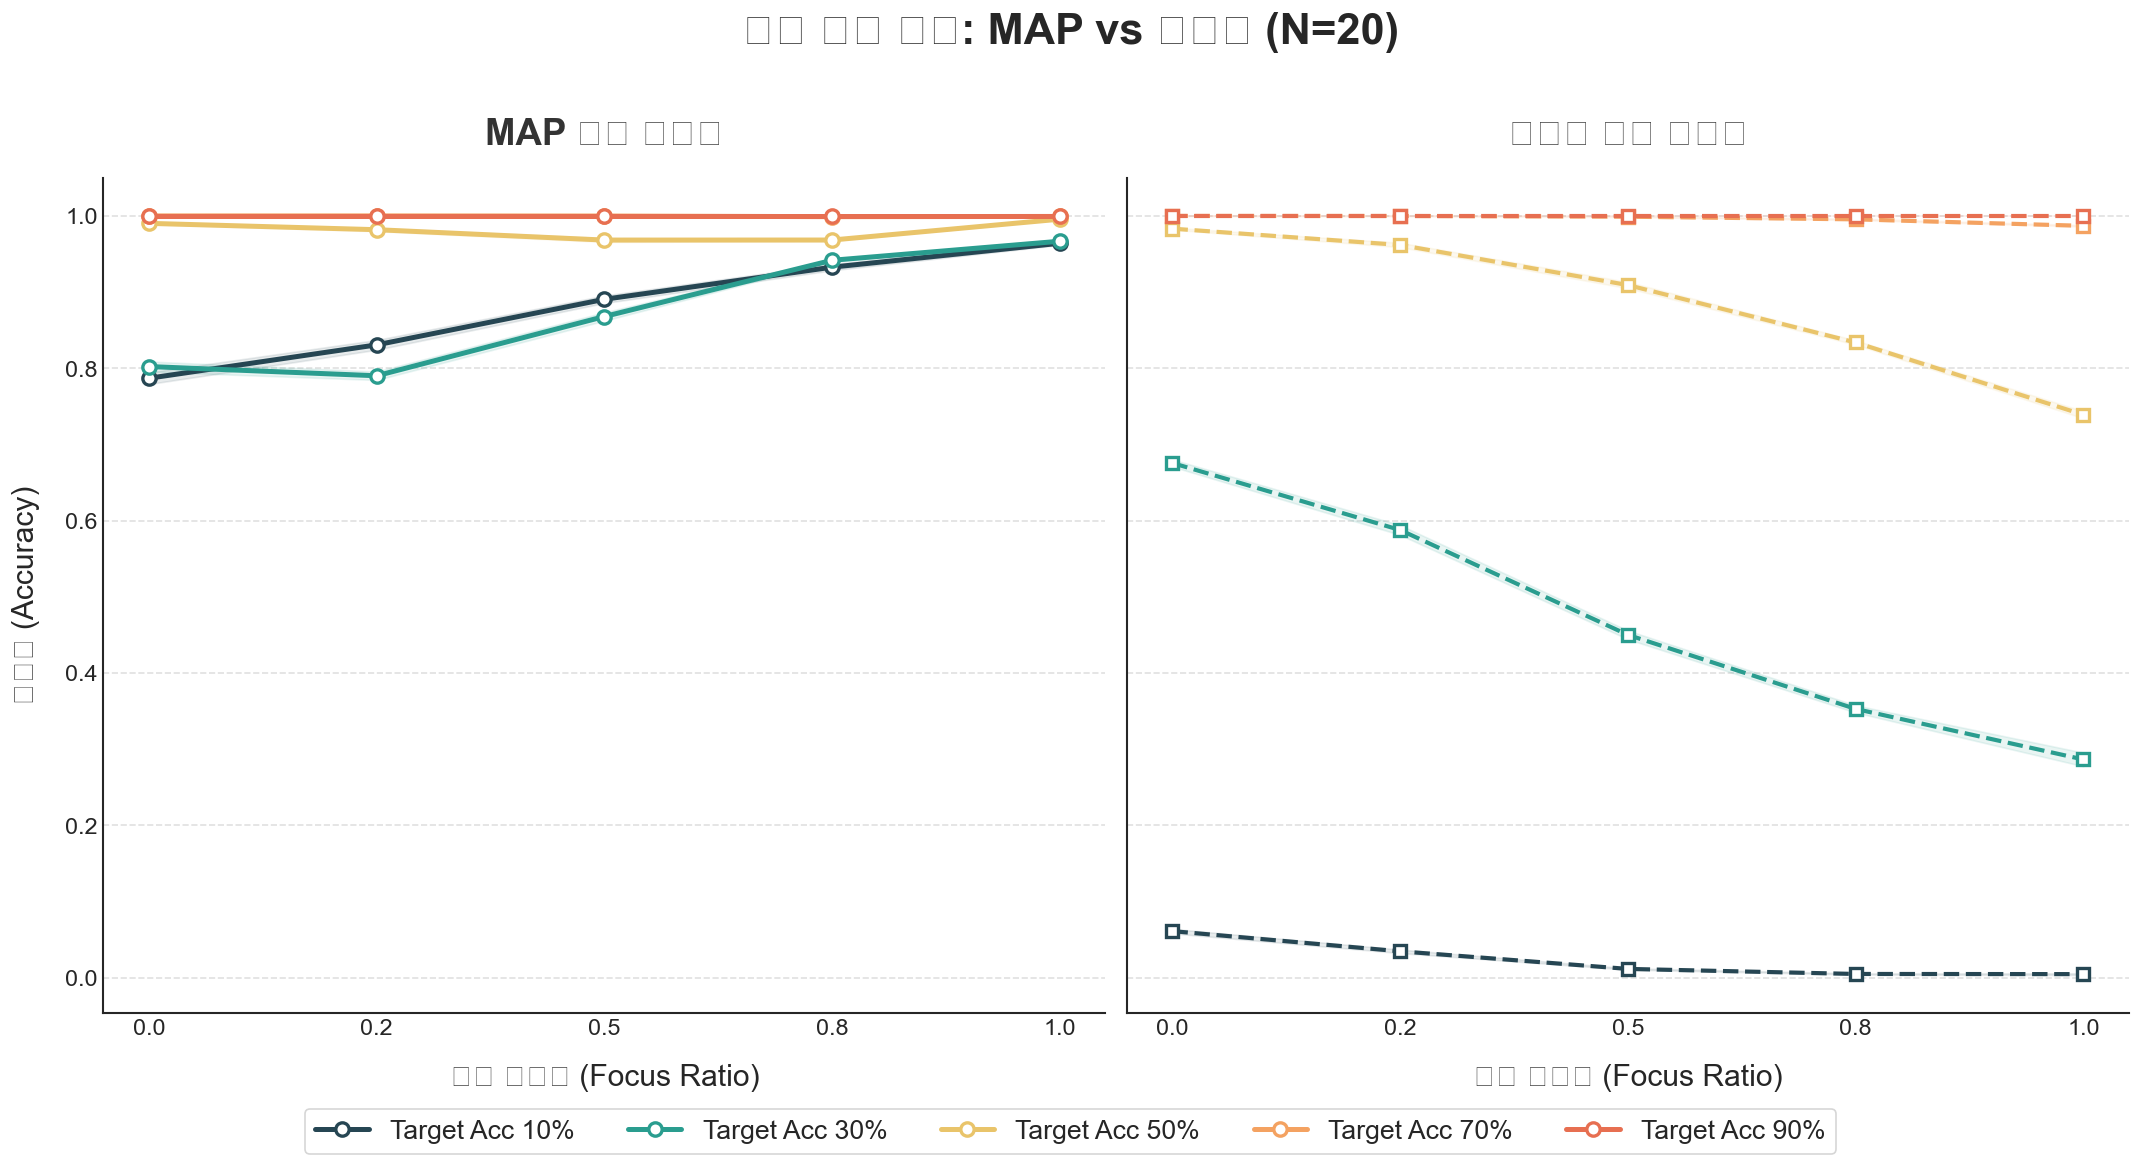

In [53]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# --- [기존 데이터 체크 로직 유지] ---
required_vars = ['diag_mean_targets', 'diag_sweep_by_target_sec6', 'focus_values', 'N_ANN_SWEEP']
if [v for v in required_vars if v not in globals()]:
    raise ValueError('데이터가 누락되었습니다.')

# --- [폰트 설정 유지 및 최적화] ---
# (기존 폰트 설정 코드는 동일하게 사용한다고 가정합니다)
matplotlib.rcParams['font.family'] = font_name
matplotlib.rcParams['axes.unicode_minus'] = False

# --- [스타일 개선 시작] ---
plt.style.use('seaborn-v0_8-white') # 조금 더 깨끗한 스타일 선택

fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True, sharey=True, dpi=120)

# 세련된 컬러 팔레트 (점진적 변화 강조)
colors = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51'] 

for i, (color, target_diag) in enumerate(zip(colors, diag_mean_targets)):
    rows = sorted(diag_sweep_by_target_sec6[float(target_diag)], key=lambda x: x['focus_ratio'])
    xs = np.array([r['focus_ratio'] for r in rows])
    
    # 데이터 추출
    map_mu, map_sd = np.array([r['map_mean'] for r in rows]), np.array([r['map_std'] for r in rows])
    maj_mu, maj_sd = np.array([r['maj_mean'] for r in rows]), np.array([r['maj_std'] for r in rows])
    
    label = f'Target Acc {target_diag:.0%}'

    # 왼쪽: MAP
    line1, = axes[0].plot(xs, map_mu, 'o-', lw=3, ms=8, color=color, label=label, markerfacecolor='white', markeredgewidth=2)
    axes[0].fill_between(xs, map_mu - map_sd, map_mu + map_sd, color=color, alpha=0.1)

    # 오른쪽: Majority Vote
    line2, = axes[1].plot(xs, maj_mu, 's--', lw=2.5, ms=7, color=color, label=label, markerfacecolor='white', markeredgewidth=2)
    axes[1].fill_between(xs, maj_mu - maj_sd, maj_mu + maj_sd, color=color, alpha=0.1)

# --- [디테일 조정] ---
titles = ['MAP 추정 정확도', '다수결 투표 정확도']
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=22, fontweight='bold', pad=20, color='#333333')
    ax.set_xlabel('오류 집중도 (Focus Ratio)', fontsize=18, labelpad=15)
    
    # 그리드 설정: 주 그리드는 점선으로 약하게
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_xticks(focus_values)
    ax.set_xticklabels([f'{x:.1f}' for x in focus_values], fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)

axes[0].set_ylabel('정확도 (Accuracy)', fontsize=18, labelpad=15)

# 전체 메인 타이틀 추가
fig.suptitle(f'모델 성능 비교: MAP vs 다수결 (N={N_ANN_SWEEP})', fontsize=26, fontweight='bold', y=1.02)

# 범례를 하단으로 이동하여 그래프를 더 크게 확보
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(diag_mean_targets), 
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

## 7. 클래스 불균형 수준별 MAP vs 다수결 비교

 설정
 - 분포 조건: 균등 / 약한 불균형 / 강한 불균형
 - 어노테이터 수준: 10%, 30%, 50%, 70%, 90%
 - 각 분포 조건에서 위 5개 어노테이터 수준의 결과를 평균

 Figure 2
 - 좌: overall accuracy (MAP vs Majority)
 - 우: minority/tail class recall (MAP vs Majority)

 주의:
 - 균등 분포에는 엄밀한 minority class가 없으므로,
   세 조건 모두 공통 비교를 위해 class 5를 reference tail class로 사용함.

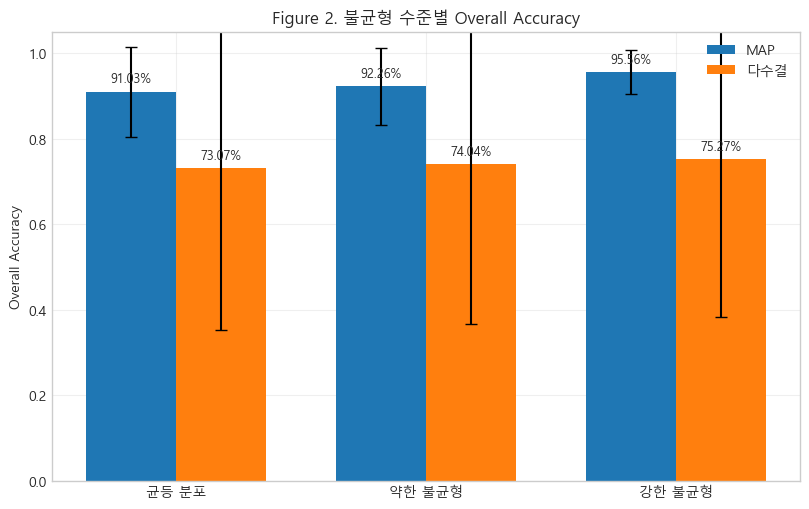

[실험 B 요약: 조건별 최종 평균 (어노테이터 수준 10/30/50/70/90 평균)]
조건              MAP Overall    Maj Overall
----------------------------------------------
균등 분포               91.03%        73.07%
약한 불균형              92.26%        74.04%
강한 불균형              95.56%        75.27%

[실험 B 상세: 조건 × 어노테이터 수준별 평균]
조건                 수준    MAP Overall    Maj Overall
----------------------------------------------------------
균등 분포            10%        78.70%         2.50%
균등 분포            30%        77.60%        64.79%
균등 분포            50%        98.83%        98.05%
균등 분포            70%       100.00%        99.99%
균등 분포            90%       100.00%       100.00%
약한 불균형           10%        81.68%         3.19%
약한 불균형           30%        80.73%        68.62%
약한 불균형           50%        98.92%        98.40%
약한 불균형           70%        99.99%        99.99%
약한 불균형           90%       100.00%       100.00%
강한 불균형           10%        89.83%         4.06%
강한 불균형           30%        88.58%        73.34%
강한 불균형  

In [13]:
# %% [markdown]
# ## 실험 B. 클래스 불균형 수준별 MAP vs 다수결 비교 (Overall만 사용)
#
# 설정
# - 분포 조건: 균등 / 약한 불균형 / 강한 불균형
# - 어노테이터 수준: 10%, 30%, 50%, 70%, 90%
# - 각 분포 조건에서 위 5개 어노테이터 수준의 결과를 평균

# %%
required_symbols = [
    'generate_annotator_confusion_matrices',
    'simulate_responses_vectorized',
    'precompute_log_cms',
    'predict_dataset_map_from_logcms',
    'majority_vote_labels_fast_lowest',
]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise ValueError(
        '먼저 이전 실험 셀들(특히 속도 우선 버전의 보조 함수 정의 셀)을 실행해주세요. '
        '누락 심볼: ' + ', '.join(missing_symbols)
    )

# -----------------------------
# 실험 B 설정
# -----------------------------
N_ANN_B = 20
ANNOTATOR_LEVELS_B = np.array([0.10, 0.30, 0.50, 0.70, 0.90], dtype=float)

IMBALANCE_CONFIGS_B = {
    '균등 분포': np.ones(NUM_CLASSES, dtype=float) / NUM_CLASSES,
    '약한 불균형': np.array([0.35, 0.25, 0.15, 0.10, 0.10, 0.05], dtype=float),
    '강한 불균형': np.array([0.70, 0.15, 0.06, 0.04, 0.03, 0.02], dtype=float),
}

# -----------------------------
# 어노테이터 수준별 pool 미리 생성
# -----------------------------
cms_by_level_B = {}
logcms_by_level_B = {}

for level in ANNOTATOR_LEVELS_B:
    level_key = float(level)
    target_cfg = {
        f'균질 그룹 ({level_key:.0%})': (int(N_ANN_B), level_key),
    }

    cms_level, _, n_ann_level = generate_annotator_confusion_matrices(
        num_classes=NUM_CLASSES,
        annotator_config=ANNOTATOR_CONFIG,
        seed=int(SEED + 120000 + round(level_key * 1000)),
        cm_generation_mode='target_accuracy',
        off_alpha=OFF_ALPHA,
        target_acc=level_key,
        target_annotator_config=target_cfg,
        accuracy_mode='uniform_weighted',
        target_base_diag_alpha=TARGET_BASE_DIAG_ALPHA,
        diag_spread=DIAG_SPREAD,
        target_offdiag_alpha=TARGET_OFFDIAG_ALPHA,
    )

    if int(n_ann_level) != int(N_ANN_B):
        raise ValueError(
            f'어노테이터 수준 {level_key:.2f}에서 어노테이터 수가 {N_ANN_B}명이 아닙니다: {n_ann_level}'
        )

    cms_by_level_B[level_key] = cms_level
    logcms_by_level_B[level_key] = precompute_log_cms(cms_level)


def mean_std_np_local(values):
    arr = np.asarray(values, dtype=float)
    return float(np.nanmean(arr)), float(np.nanstd(arr, ddof=0))


# -----------------------------
# 본 실험 (Overall Accuracy만 계산)
# -----------------------------
expB_level_summary = []
expB_condition_summary = []

for cond_idx, (cond_name, cond_probs) in enumerate(IMBALANCE_CONFIGS_B.items()):
    cond_probs = np.asarray(cond_probs, dtype=float)
    cond_probs = cond_probs / cond_probs.sum()

    map_overall_by_level = []
    maj_overall_by_level = []

    for level in ANNOTATOR_LEVELS_B:
        level_key = float(level)
        cms_level = cms_by_level_B[level_key]
        logcms_level = logcms_by_level_B[level_key]

        map_overall_runs = []
        maj_overall_runs = []

        for seed in SEED_LIST:
            seed_offset = cond_idx * 100000 + int(round(level_key * 1000)) * 100

            rng_labels = np.random.default_rng(int(seed + 130000 + seed_offset))
            true_labels_case = rng_labels.choice(NUM_CLASSES, size=NUM_SAMPLES, p=cond_probs)

            prior_case = np.bincount(true_labels_case, minlength=NUM_CLASSES).astype(float)
            prior_case /= prior_case.sum()

            responses_case = simulate_responses_vectorized(
                cms_level,
                true_labels_case,
                seed=int(seed + 140000 + seed_offset),
            )

            preds_map, _ = predict_dataset_map_from_logcms(
                responses_case,
                logcms_level,
                prior_case,
            )
            preds_maj = majority_vote_labels_fast_lowest(
                responses_case,
                NUM_CLASSES,
            )

            map_overall_runs.append(float(np.mean(preds_map == true_labels_case)))
            maj_overall_runs.append(float(np.mean(preds_maj == true_labels_case)))

        map_overall_mu, map_overall_sd = mean_std_np_local(map_overall_runs)
        maj_overall_mu, maj_overall_sd = mean_std_np_local(maj_overall_runs)

        expB_level_summary.append({
            'condition': cond_name,
            'annotator_level': level_key,
            'map_overall_mean': map_overall_mu,
            'map_overall_std': map_overall_sd,
            'maj_overall_mean': maj_overall_mu,
            'maj_overall_std': maj_overall_sd,
        })

        map_overall_by_level.append(map_overall_mu)
        maj_overall_by_level.append(maj_overall_mu)

    expB_condition_summary.append({
        'condition': cond_name,
        'map_overall_mean': float(np.mean(map_overall_by_level)),
        'maj_overall_mean': float(np.mean(maj_overall_by_level)),
        'map_overall_std_over_levels': float(np.std(map_overall_by_level, ddof=0)),
        'maj_overall_std_over_levels': float(np.std(maj_overall_by_level, ddof=0)),
    })


# -----------------------------
# Figure 2 시각화 (Overall만)
# -----------------------------
condition_order_B = ['균등 분포', '약한 불균형', '강한 불균형']
summary_B = {row['condition']: row for row in expB_condition_summary}

map_overall_vals = [summary_B[c]['map_overall_mean'] for c in condition_order_B]
maj_overall_vals = [summary_B[c]['maj_overall_mean'] for c in condition_order_B]
map_overall_err = [summary_B[c]['map_overall_std_over_levels'] for c in condition_order_B]
maj_overall_err = [summary_B[c]['maj_overall_std_over_levels'] for c in condition_order_B]

from matplotlib import font_manager
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR']:
    if font_name in available_fonts:
        KOREAN_FONT_B = font_name
        break
else:
    KOREAN_FONT_B = None

if KOREAN_FONT_B is not None:
    matplotlib.rcParams['font.family'] = KOREAN_FONT_B
    matplotlib.rcParams['axes.unicode_minus'] = False

with plt.style.context('seaborn-v0_8-whitegrid'):
    if KOREAN_FONT_B is not None:
        plt.rcParams['font.family'] = KOREAN_FONT_B
        plt.rcParams['axes.unicode_minus'] = False

    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    x = np.arange(len(condition_order_B))
    width = 0.36

    bars1 = ax.bar(
        x - width/2,
        map_overall_vals,
        width,
        yerr=map_overall_err,
        capsize=4,
        label='MAP',
    )
    bars2 = ax.bar(
        x + width/2,
        maj_overall_vals,
        width,
        yerr=maj_overall_err,
        capsize=4,
        label='다수결',
    )

    ax.set_xticks(x)
    ax.set_xticklabels(condition_order_B)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Overall Accuracy')
    ax.set_title('Figure 2. 불균형 수준별 Overall Accuracy')
    ax.legend()

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.015,
                f'{h:.2%}',
                ha='center',
                va='bottom',
                fontsize=9,
            )

    plt.tight_layout()
    plt.show()


# -----------------------------
# 요약 출력 (Overall만)
# -----------------------------
print('[실험 B 요약: 조건별 최종 평균 (어노테이터 수준 10/30/50/70/90 평균)]')
print(
    f"{'조건':<12} "
    f"{'MAP Overall':>14} {'Maj Overall':>14}"
)
print('-' * 46)
for cond in condition_order_B:
    row = summary_B[cond]
    print(
        f"{cond:<12} "
        f"{row['map_overall_mean']:>13.2%} "
        f"{row['maj_overall_mean']:>13.2%}"
    )

print('\n[실험 B 상세: 조건 × 어노테이터 수준별 평균]')
print(
    f"{'조건':<12} {'수준':>8} "
    f"{'MAP Overall':>14} {'Maj Overall':>14}"
)
print('-' * 58)
for row in expB_level_summary:
    print(
        f"{row['condition']:<12} "
        f"{row['annotator_level']:>7.0%} "
        f"{row['map_overall_mean']:>13.2%} "
        f"{row['maj_overall_mean']:>13.2%}"
    )

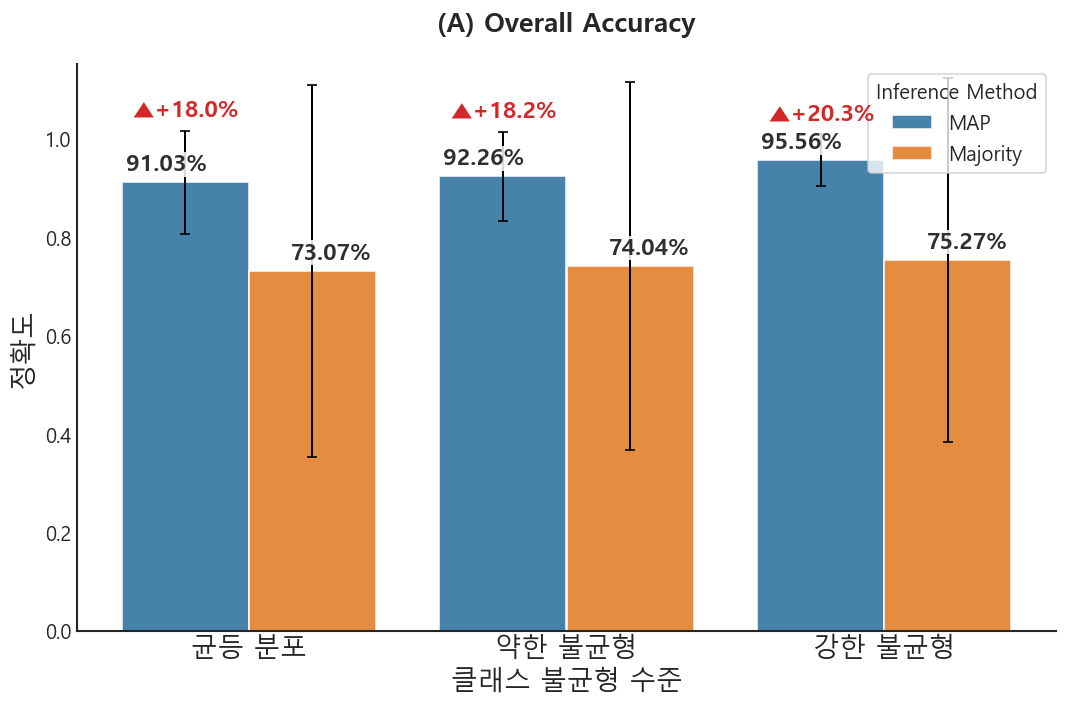

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

# summary_B에서 overall 지표만 사용
data_list = []
for cond in condition_order_B:
    res = summary_B[cond]
    data_list.append({
        'Condition': cond,
        'Method': 'MAP',
        'Overall': res['map_overall_mean'],
        'Overall_Std': res['map_overall_std_over_levels'],
    })
    data_list.append({
        'Condition': cond,
        'Method': 'Majority',
        'Overall': res['maj_overall_mean'],
        'Overall_Std': res['maj_overall_std_over_levels'],
    })

df_plot = pd.DataFrame(data_list)

plt.style.use('seaborn-v0_8-white')

# 한글 폰트 고정
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ['Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR', 'AppleGothic', 'DejaVu Sans']:
    if font_name in available_fonts:
        PLOT_FONT = font_name
        break
else:
    PLOT_FONT = 'DejaVu Sans'

matplotlib.rcParams['font.family'] = PLOT_FONT
matplotlib.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(9.0, 6.0), dpi=120)
palette = {'MAP': '#1f77b4', 'Majority': '#ff7f0e'}

sns.barplot(
    data=df_plot,
    x='Condition',
    y='Overall',
    hue='Method',
    palette=palette,
    ax=ax,
    capsize=.05,
    errorbar=None,
    alpha=0.9,
    edgecolor='white',
)

# 오차 막대 + 막대 끝점 숫자 + MAP 이점 표시
for j, cond in enumerate(condition_order_B):
    map_row = df_plot[(df_plot['Condition'] == cond) & (df_plot['Method'] == 'MAP')].iloc[0]
    maj_row = df_plot[(df_plot['Condition'] == cond) & (df_plot['Method'] == 'Majority')].iloc[0]

    map_y = map_row['Overall']
    maj_y = maj_row['Overall']
    map_err = map_row['Overall_Std']
    maj_err = maj_row['Overall_Std']

    x_map = j - 0.2
    x_maj = j + 0.2

    # 숫자 라벨을 가리지 않도록 오차막대 zorder를 낮춤
    ax.errorbar(x_map, map_y, yerr=map_err, fmt='none', c='black', lw=1.2, capsize=3, zorder=2)
    ax.errorbar(x_maj, maj_y, yerr=maj_err, fmt='none', c='black', lw=1.2, capsize=3, zorder=2)

    # 세로 오차막대와 겹치지 않게 라벨을 좌우로 살짝 이동 + 배경 박스 적용
    ax.text(
        x_map - 0.06,
        map_y + 0.014,
        f'{map_y:.2%}',
        ha='center',
        va='bottom',
        color='#2f2f2f',
        fontsize=14,
        fontweight='semibold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=0.8),
        zorder=6,
    )
    ax.text(
        x_maj + 0.06,
        maj_y + 0.014,
        f'{maj_y:.2%}',
        ha='center',
        va='bottom',
        color='#2f2f2f',
        fontsize=14,
        fontweight='semibold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=0.8),
        zorder=6,
    )

    gap = map_y - maj_y
    ax.text(
        x_map,
        map_y + map_err + 0.02,
        f"▲{gap:+.1%}",
        ha='center',
        va='bottom',
        color='#d62728',
        fontweight='bold',
        fontsize=14,
        zorder=7,
    )

ax.set_ylim(0, 1.15)
ax.set_title('(A) Overall Accuracy', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('정확도', fontsize=16)
ax.set_xlabel('클래스 불균형 수준', fontsize=16)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for tick in ax.get_xticklabels():
    tick.set_fontfamily(PLOT_FONT)
    tick.set_fontsize(16)

ax.tick_params(axis='y', labelsize=12)
ax.legend(title='Inference Method', frameon=True, loc='upper right', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

## 8. 라벨러 풀 구성과 전문가 포함 효과


[동질 풀 결과 | 공통 baseline]
동질 다수결: 66.78% ± 1.50%
동질 MAP   : 80.73% ± 1.28%

[시나리오] 전문가 정확도 50% 추가 (expert_acc=50%)
    전문가(a)     중급자(b)     초보자(c)         이질 다수결         이질 MAP      MAP-다수결
----------------------------------------------------------------------------
         0         20          0        66.83%        80.23%     +13.40%
         1         18          1        68.24%        83.18%     +14.94%
         2         16          2        67.58%        85.71%     +18.12%
         3         14          3        68.05%        87.32%     +19.26%
         4         12          4        67.95%        89.02%     +21.07%
         5         10          5        69.36%        90.53%     +21.17%
         6          8          6        68.59%        91.90%     +23.32%
         7          6          7        69.27%        93.13%     +23.86%
         8          4          8        68.96%        93.78%     +24.82%
         9          2          9        70.32%        94.50%     +24.19%
    

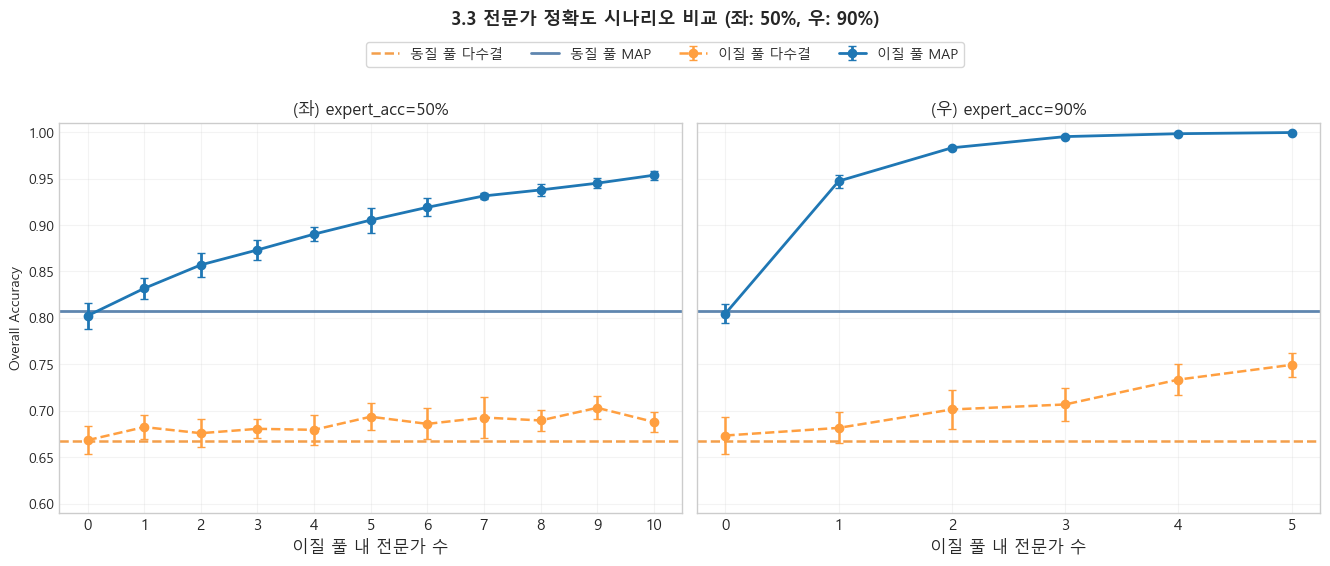

In [15]:
# %% [markdown]
# ## 8. 라벨러 풀 구성과 전문가 포함 효과
#
# Figure 구성
# - 왼쪽: 정확도 50% 전문가를 점진적으로 추가
# - 오른쪽: 정확도 90% 전문가를 점진적으로 추가
# - 두 경우 모두 전체 50명, 평균 정확도 30% 유지

# %%
required_symbols = [
    'generate_annotator_confusion_matrices',
    'build_class_probs',
    'simulate_responses_vectorized',
    'precompute_log_cms',
    'predict_dataset_map_from_logcms',
    'majority_vote_labels_fast_lowest',
]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise ValueError(
        '먼저 이전 셀들을 실행해주세요. 누락 심볼: ' + ', '.join(missing_symbols)
    )

# -----------------------------
# 실험 설정
# -----------------------------
POOL_TOTAL = 20
TARGET_MEAN_ACC = 0.30

ACC_MID = 0.30
ACC_NOVICE = 0.10

EXPERT_SCENARIOS = {
    '전문가 정확도 50% 추가': 0.50,
    '전문가 정확도 90% 추가': 0.90,
}

# 클래스 분포는 현재 노트북 기본 설정(class_probs) 사용
if 'class_probs' in globals():
    class_probs_pool = np.asarray(class_probs, dtype=float)
else:
    class_probs_pool = build_class_probs(
        num_classes=NUM_CLASSES,
        class_dist_mode=CLASS_DIST_MODE,
        custom_class_probs=CUSTOM_CLASS_PROBS,
    )
class_probs_pool = class_probs_pool / class_probs_pool.sum()

# -----------------------------
# 보조 함수
# -----------------------------
def mean_std_np_local(values):
    arr = np.asarray(values, dtype=float)
    return float(np.mean(arr)), float(np.std(arr, ddof=0))


def solve_hetero_counts(total, mean_target, acc_exp, acc_mid, acc_nov, n_exp):
    """
    평균 정확도 mean_target, 전체 total을 유지하도록
    전문가 n_exp일 때 (n_exp, n_mid, n_nov) 계산.
    """
    denom = (mean_target - acc_nov)
    if denom <= 0:
        raise ValueError('acc_nov는 mean_target보다 작아야 합니다.')

    n_nov_float = ((acc_exp - mean_target) / denom) * n_exp
    n_nov = int(round(n_nov_float))

    if abs(n_nov - n_nov_float) > 1e-8:
        raise ValueError(
            f'정수 조합이 깔끔하지 않습니다. acc_exp={acc_exp}, n_exp={n_exp}, n_nov_float={n_nov_float}'
        )

    n_mid = int(total - n_exp - n_nov)
    if n_mid < 0:
        raise ValueError(
            f'유효하지 않은 조합입니다. acc_exp={acc_exp}, n_exp={n_exp}, n_mid={n_mid}, n_nov={n_nov}'
        )

    avg = (acc_exp * n_exp + acc_mid * n_mid + acc_nov * n_nov) / total
    if not np.isclose(avg, mean_target, atol=1e-12):
        raise ValueError(f'평균 정확도 불일치: {avg} != {mean_target}')

    return int(n_exp), int(n_mid), int(n_nov)


def get_feasible_expert_counts(total, mean_target, acc_exp, acc_nov):
    """해당 전문가 정확도에서 가능한 전문가 수 a 목록 반환."""
    ratio = 1.0 + (acc_exp - mean_target) / (mean_target - acc_nov)
    if ratio <= 0:
        raise ValueError('유효하지 않은 ratio입니다.')
    max_a = int(np.floor(total / ratio + 1e-12))
    return np.arange(0, max_a + 1, dtype=int)


def make_target_cfg_homogeneous():
    return {
        '중급자': (int(POOL_TOTAL), float(ACC_MID)),
    }


def make_target_cfg_heterogeneous(acc_exp, n_exp):
    n_exp, n_mid, n_nov = solve_hetero_counts(
        total=POOL_TOTAL,
        mean_target=TARGET_MEAN_ACC,
        acc_exp=float(acc_exp),
        acc_mid=ACC_MID,
        acc_nov=ACC_NOVICE,
        n_exp=int(n_exp),
    )
    return {
        '전문가': (n_exp, float(acc_exp)),
        '중급자': (n_mid, float(ACC_MID)),
        '초보자': (n_nov, float(ACC_NOVICE)),
    }


def evaluate_pool_once(target_cfg, seed_base, true_labels_case, prior_case):
    cms_pool, _, n_ann_pool = generate_annotator_confusion_matrices(
        num_classes=NUM_CLASSES,
        annotator_config=ANNOTATOR_CONFIG,
        seed=int(seed_base),
        cm_generation_mode='target_accuracy',
        off_alpha=OFF_ALPHA,
        target_acc=TARGET_ACC,
        target_annotator_config=target_cfg,
        accuracy_mode='uniform_weighted',
        target_base_diag_alpha=TARGET_BASE_DIAG_ALPHA,
        diag_spread=DIAG_SPREAD,
        target_offdiag_alpha=TARGET_OFFDIAG_ALPHA,
    )

    logcms_pool = precompute_log_cms(cms_pool)

    responses_case = simulate_responses_vectorized(
        cms_pool,
        true_labels_case,
        seed=int(seed_base + 1),
    )

    preds_map, _ = predict_dataset_map_from_logcms(
        responses_case,
        logcms_pool,
        prior_case,
    )
    preds_maj = majority_vote_labels_fast_lowest(
        responses_case,
        NUM_CLASSES,
    )

    map_acc = float(np.mean(preds_map == true_labels_case))
    maj_acc = float(np.mean(preds_maj == true_labels_case))

    return {
        'num_annotators': int(n_ann_pool),
        'map_acc': map_acc,
        'maj_acc': maj_acc,
    }


# -----------------------------
# 동질 풀 baseline (시나리오 공통)
# -----------------------------
hom_majority_runs = []
hom_map_runs = []

for seed in SEED_LIST:
    rng_labels_case = np.random.default_rng(int(seed + 210000))
    true_labels_case = rng_labels_case.choice(
        NUM_CLASSES,
        size=NUM_SAMPLES,
        p=class_probs_pool,
    )
    prior_case = np.bincount(true_labels_case, minlength=NUM_CLASSES).astype(float)
    prior_case /= prior_case.sum()

    hom_result = evaluate_pool_once(
        target_cfg=make_target_cfg_homogeneous(),
        seed_base=int(seed + 220000),
        true_labels_case=true_labels_case,
        prior_case=prior_case,
    )
    hom_majority_runs.append(hom_result['maj_acc'])
    hom_map_runs.append(hom_result['map_acc'])

hom_majority_mean, hom_majority_std = mean_std_np_local(hom_majority_runs)
hom_map_mean, hom_map_std = mean_std_np_local(hom_map_runs)


# -----------------------------
# 시나리오별 이질 풀 평가
# -----------------------------
scenario_results = {}

for sc_idx, (scenario_name, acc_exp) in enumerate(EXPERT_SCENARIOS.items()):
    expert_counts = get_feasible_expert_counts(
        total=POOL_TOTAL,
        mean_target=TARGET_MEAN_ACC,
        acc_exp=float(acc_exp),
        acc_nov=ACC_NOVICE,
    )

    hetero_majority_by_a = {int(a): [] for a in expert_counts}
    hetero_map_by_a = {int(a): [] for a in expert_counts}

    for seed in SEED_LIST:
        rng_labels_case = np.random.default_rng(int(seed + 210000))
        true_labels_case = rng_labels_case.choice(
            NUM_CLASSES,
            size=NUM_SAMPLES,
            p=class_probs_pool,
        )
        prior_case = np.bincount(true_labels_case, minlength=NUM_CLASSES).astype(float)
        prior_case /= prior_case.sum()

        for a in expert_counts:
            het_result = evaluate_pool_once(
                target_cfg=make_target_cfg_heterogeneous(float(acc_exp), int(a)),
                seed_base=int(seed + 230000 + sc_idx * 20000 + int(a) * 1000),
                true_labels_case=true_labels_case,
                prior_case=prior_case,
            )
            hetero_majority_by_a[int(a)].append(het_result['maj_acc'])
            hetero_map_by_a[int(a)].append(het_result['map_acc'])

    hetero_majority_mean = []
    hetero_majority_std = []
    hetero_map_mean = []
    hetero_map_std = []
    composition_rows = []

    for a in expert_counts:
        mu_maj, sd_maj = mean_std_np_local(hetero_majority_by_a[int(a)])
        mu_map, sd_map = mean_std_np_local(hetero_map_by_a[int(a)])

        hetero_majority_mean.append(mu_maj)
        hetero_majority_std.append(sd_maj)
        hetero_map_mean.append(mu_map)
        hetero_map_std.append(sd_map)

        a_, b_, c_ = solve_hetero_counts(
            total=POOL_TOTAL,
            mean_target=TARGET_MEAN_ACC,
            acc_exp=float(acc_exp),
            acc_mid=ACC_MID,
            acc_nov=ACC_NOVICE,
            n_exp=int(a),
        )
        composition_rows.append((a_, b_, c_))

    scenario_results[scenario_name] = {
        'acc_exp': float(acc_exp),
        'expert_counts': np.asarray(expert_counts, dtype=int),
        'hetero_majority_mean': np.asarray(hetero_majority_mean, dtype=float),
        'hetero_majority_std': np.asarray(hetero_majority_std, dtype=float),
        'hetero_map_mean': np.asarray(hetero_map_mean, dtype=float),
        'hetero_map_std': np.asarray(hetero_map_std, dtype=float),
        'composition_rows': composition_rows,
    }


# -----------------------------
# 조합표 + 성능표 출력
# -----------------------------
print('[동질 풀 결과 | 공통 baseline]')
print(f"동질 다수결: {hom_majority_mean:.2%} ± {hom_majority_std:.2%}")
print(f"동질 MAP   : {hom_map_mean:.2%} ± {hom_map_std:.2%}")

for scenario_name, acc_exp in EXPERT_SCENARIOS.items():
    res = scenario_results[scenario_name]
    print(f"\n[시나리오] {scenario_name} (expert_acc={acc_exp:.0%})")
    print(f"{'전문가(a)':>10} {'중급자(b)':>10} {'초보자(c)':>10} {'이질 다수결':>14} {'이질 MAP':>14} {'MAP-다수결':>12}")
    print('-' * 76)

    for i, a in enumerate(res['expert_counts']):
        a_, b_, c_ = res['composition_rows'][i]
        maj_v = res['hetero_majority_mean'][i]
        map_v = res['hetero_map_mean'][i]
        print(
            f"{a_:>10d} {b_:>10d} {c_:>10d} "
            f"{maj_v:>13.2%} {map_v:>13.2%} {(map_v - maj_v):>+11.2%}"
        )


# -----------------------------
# 시각화 (좌: 50%, 우: 90%)
# -----------------------------
from matplotlib import font_manager
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR']:
    if font_name in available_fonts:
        KOREAN_FONT_33 = font_name
        break
else:
    KOREAN_FONT_33 = None

if KOREAN_FONT_33 is not None:
    matplotlib.rcParams['font.family'] = KOREAN_FONT_33
    matplotlib.rcParams['axes.unicode_minus'] = False

# 두 패널이 동일 스케일을 공유하도록 y축 범위를 전체 데이터 기준으로 계산
all_y_candidates = [
    hom_majority_mean - hom_majority_std,
    hom_majority_mean + hom_majority_std,
    hom_map_mean - hom_map_std,
    hom_map_mean + hom_map_std,
]
for scenario_name in EXPERT_SCENARIOS.keys():
    rr = scenario_results[scenario_name]
    all_y_candidates.append(np.min(rr['hetero_majority_mean'] - rr['hetero_majority_std']))
    all_y_candidates.append(np.max(rr['hetero_majority_mean'] + rr['hetero_majority_std']))
    all_y_candidates.append(np.min(rr['hetero_map_mean'] - rr['hetero_map_std']))
    all_y_candidates.append(np.max(rr['hetero_map_mean'] + rr['hetero_map_std']))

y_min = float(np.min(all_y_candidates))
y_max = float(np.max(all_y_candidates))
span = max(1e-6, y_max - y_min)
y_pad = max(0.01, 0.18 * span)
y_lower = max(0.0, y_min - y_pad)
y_upper = min(1.01, y_max + y_pad)

with plt.style.context('seaborn-v0_8-whitegrid'):
    if KOREAN_FONT_33 is not None:
        plt.rcParams['font.family'] = KOREAN_FONT_33
        plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.2), sharey=True)
    panel_labels = ['(좌)', '(우)']

    for idx, ((scenario_name, acc_exp), ax) in enumerate(zip(EXPERT_SCENARIOS.items(), axes)):
        rr = scenario_results[scenario_name]
        x_vals = rr['expert_counts']

        ax.axhline(
            hom_majority_mean,
            linestyle='--',
            linewidth=1.8,
            color='#f28e2b',
            alpha=0.85,
            label='동질 풀 다수결',
        )
        ax.axhline(
            hom_map_mean,
            linestyle='-',
            linewidth=2.0,
            color='#4e79a7',
            alpha=0.9,
            label='동질 풀 MAP',
        )

        ax.errorbar(
            x_vals,
            rr['hetero_majority_mean'],
            yerr=rr['hetero_majority_std'],
            fmt='o--',
            capsize=3,
            linewidth=1.8,
            color='#ff9f40',
            label='이질 풀 다수결',
        )
        ax.errorbar(
            x_vals,
            rr['hetero_map_mean'],
            yerr=rr['hetero_map_std'],
            fmt='o-',
            capsize=3,
            linewidth=2.0,
            color='#1f77b4',
            label='이질 풀 MAP',
        )

        ax.set_ylim(y_lower, y_upper)
        ax.grid(True, alpha=0.22)
        ax.set_xlabel('이질 풀 내 전문가 수', fontsize=12)
        ax.set_title(f"{panel_labels[idx]} expert_acc={acc_exp:.0%}")

        # 전문가 수가 많은 패널(50%)에서도 x축이 과밀하지 않게 간격 조절
        step = 1 if len(x_vals) <= 15 else 2
        ax.set_xticks(x_vals[::step])
        ax.tick_params(axis='x', labelsize=11)

    axes[0].set_ylabel('Overall Accuracy')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=4, frameon=True, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle('3.3 전문가 정확도 시나리오 비교 (좌: 50%, 우: 90%)', fontsize=13, fontweight='bold', y=1.08)

    plt.tight_layout()
    plt.show()

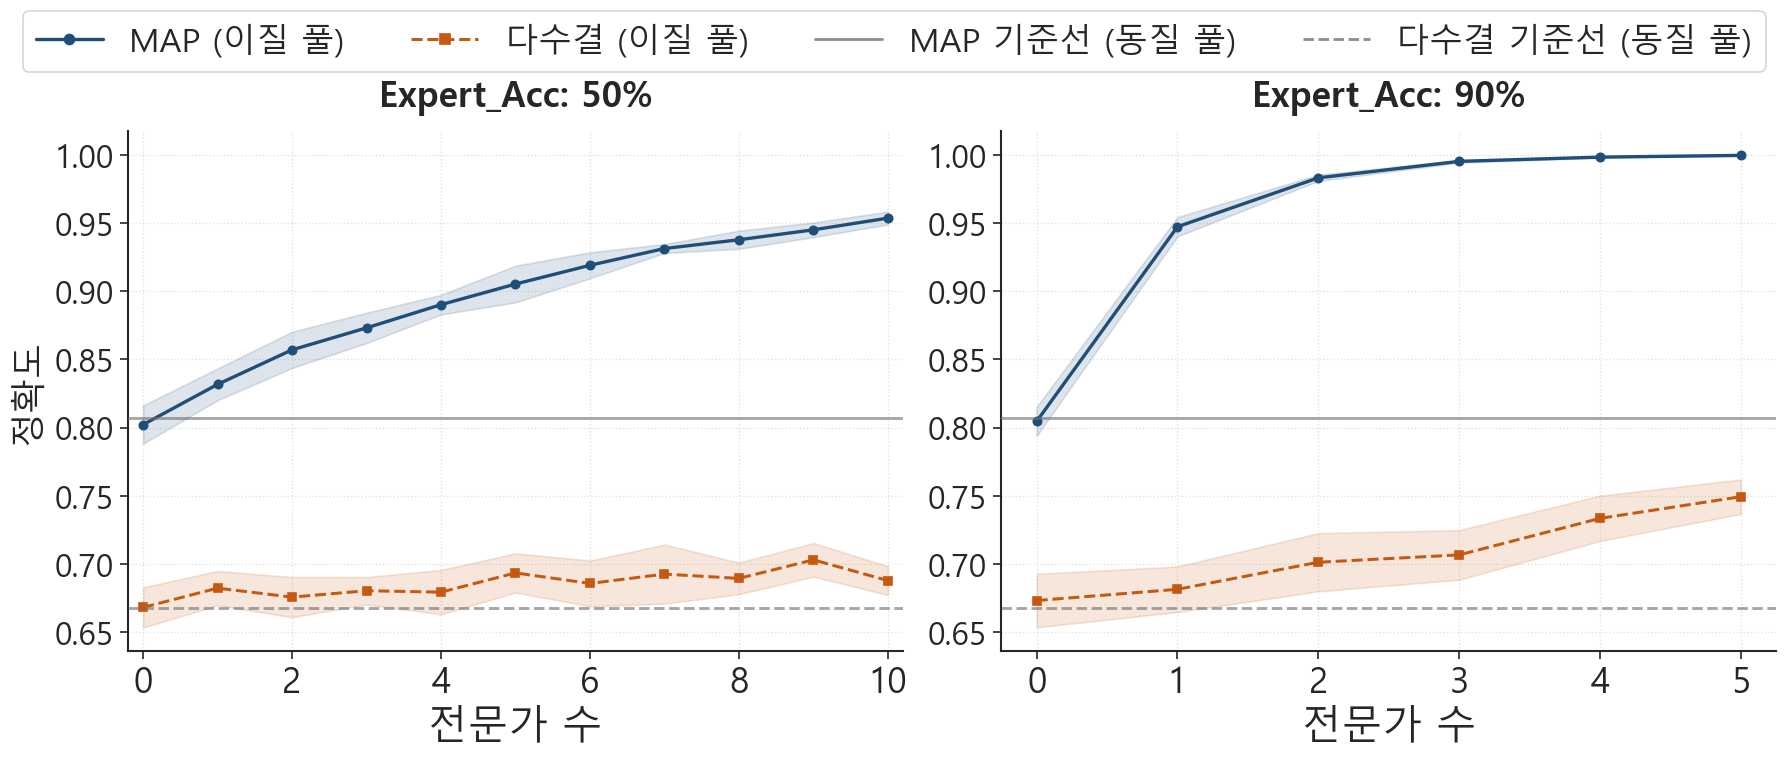

In [16]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager as fm

# ==========================================
# 1. 데이터 정리 (Plotting을 위한 DataFrame화)
# ==========================================
plot_data = []

# Baseline 데이터 준비
baseline = {
    'hom_maj_mu': hom_majority_mean, 'hom_maj_sd': hom_majority_std,
    'hom_map_mu': hom_map_mean, 'hom_map_sd': hom_map_std
}

# 시나리오 데이터 변환
for sc_name, res in scenario_results.items():
    acc_label = f"Expert_Acc: {res['acc_exp']:.0%}"
    for i, a in enumerate(res['expert_counts']):
        # MAP 데이터
        plot_data.append({
            'Scenario': acc_label, 'Expert Count': a, 'Method': 'Hetero MAP',
            'Accuracy': res['hetero_map_mean'][i], 'Std': res['hetero_map_std'][i]
        })
        # 다수결 데이터
        plot_data.append({
            'Scenario': acc_label, 'Expert Count': a, 'Method': 'Hetero Majority',
            'Accuracy': res['hetero_majority_mean'][i], 'Std': res['hetero_majority_std'][i]
        })

df_plot = pd.DataFrame(plot_data)

# ==========================================
# 2. 시각화 설정 (Academic Style)
# ==========================================
plt.style.use('seaborn-v0_8-white')

# 한글 폰트 고정
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ['Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR', 'AppleGothic', 'DejaVu Sans']:
    if font_name in available_fonts:
        PLOT_FONT_33 = font_name
        break
else:
    PLOT_FONT_33 = 'DejaVu Sans'

matplotlib.rcParams['font.family'] = PLOT_FONT_33
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True, dpi=120)

# 컬러 팔레트 설정
colors = {
    'MAP_Main': '#1F4E79',      # 짙은 블루 (신뢰감)
    'MAP_Light': '#D9E1F2',
    'Maj_Main': '#C65911',      # 짙은 오렌지 (대조군)
    'Maj_Light': '#FCE4D6',
    'Base_Line': '#6F6F6F'      # 회색 (기준선, 그리드 대비 소폭 강화)
}

scenarios = df_plot['Scenario'].unique()

for i, sc in enumerate(scenarios):
    ax = axes[i]
    sub = df_plot[df_plot['Scenario'] == sc]

    # --- A. 동질 풀(Baseline) 가이드라인 ---
    ax.axhline(baseline['hom_map_mu'], color=colors['Base_Line'], lw=1.7, ls='-', alpha=0.62, zorder=3)
    ax.axhline(baseline['hom_maj_mu'], color=colors['Base_Line'], lw=1.7, ls='--', alpha=0.62, zorder=3)

    # --- B. Hetero MAP (Shaded + Line) ---
    m_data = sub[sub['Method'] == 'Hetero MAP']
    ax.fill_between(m_data['Expert Count'], m_data['Accuracy'] - m_data['Std'],
                    m_data['Accuracy'] + m_data['Std'], color=colors['MAP_Main'], alpha=0.15)
    ax.plot(m_data['Expert Count'], m_data['Accuracy'], marker='o', ms=5,
            color=colors['MAP_Main'], lw=2, label='Proposed (MAP)')

    # --- C. Hetero Majority (Shaded + Line) ---
    j_data = sub[sub['Method'] == 'Hetero Majority']
    ax.fill_between(j_data['Expert Count'], j_data['Accuracy'] - j_data['Std'],
                    j_data['Accuracy'] + j_data['Std'], color=colors['Maj_Main'], alpha=0.15)
    ax.plot(j_data['Expert Count'], j_data['Accuracy'], marker='s', ms=5, ls='--',
            color=colors['Maj_Main'], lw=1.8, label='Majority Vote')

    # --- D. 차트 디테일 ---
    ax.set_title(f'{sc}', fontsize=21, fontweight='bold', pad=15)
    ax.set_xlabel('전문가 수', fontsize=24)
    if i == 0:
        ax.set_ylabel('정확도', fontsize=21)

    # 그리드 및 스파인 정리
    ax.grid(True, axis='both', ls=':', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # x축 눈금 정리
    if i == 0:  # 왼쪽 패널 x축 범위/눈금 고정 + 양끝 여백
        ax.set_xlim(-0.2, 10.2)
        ax.set_xticks(range(0, 11, 2))

    # x/y 축 눈금을 동일 스타일로 적용
    ax.tick_params(axis='x', labelsize=21, length=5, width=1)
    ax.tick_params(axis='y', labelsize=19, length=5, width=1, left=True, labelleft=True)

# sharey 환경에서도 두 패널의 y축 눈금을 보이도록 유지
axes[1].tick_params(axis='y', left=True, labelleft=True)

# ==========================================
# 3. 통합 범례 및 마무리
# ==========================================
# 수동으로 범례 항목 생성 (중복 방지)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors['MAP_Main'], lw=2, marker='o', label='MAP (이질 풀)'),
    Line2D([0], [0], color=colors['Maj_Main'], lw=1.8, marker='s', ls='--', label='다수결 (이질 풀)'),
    Line2D([0], [0], color=colors['Base_Line'], lw=1.7, ls='-', alpha=0.78, label='MAP 기준선 (동질 풀)'),
    Line2D([0], [0], color=colors['Base_Line'], lw=1.7, ls='--', alpha=0.78, label='다수결 기준선 (동질 풀)')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.07),
           ncol=4, frameon=True, fontsize=20)

plt.tight_layout()
plt.subplots_adjust(top=0.88)  # 범례 공간 확보
plt.show()

## 9. 종합

focused_cms / log_cms 캐시 생성 중...
focused_cms / log_cms 캐시 완료 ✓
디스크 캐시 재사용 ✓  (c:\Users\최현준\Desktop\Projects\pseudo_GT\_threshold_cache\surface_map90_b1c3e639fdf8a059067e570b927bfb21.pkl)


C:\Users\최현준\AppData\Local\Temp\ipykernel_18108\3716815089.py:482: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


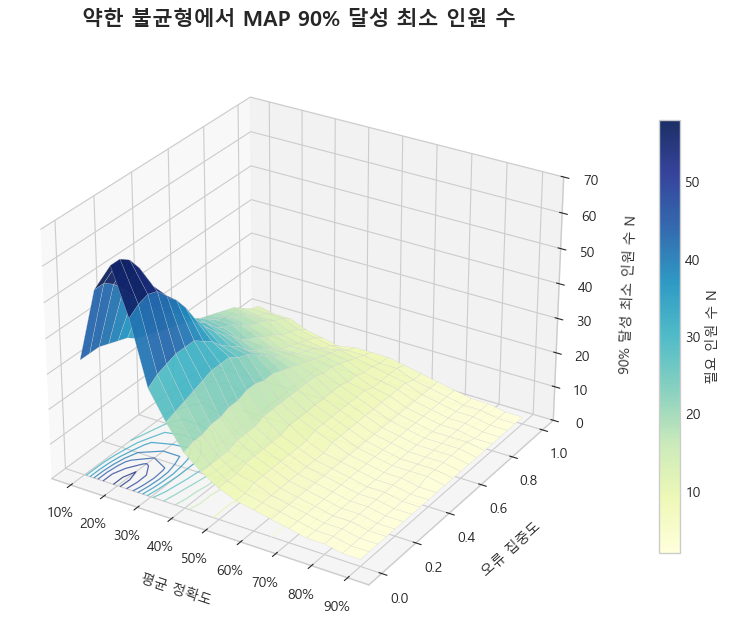

[MAP 90% 달성 최소 인원 수 요약표]
     평균정확도      오류집중도     최종MAP@20      N90
----------------------------------------------
      10%      0.00      99.83%       33
      10%      0.05      99.84%       33
      10%      0.10      99.80%       33
      10%      0.15      99.83%       32
      10%      0.20      99.83%       31
      10%      0.25      99.80%       30
      10%      0.30      99.80%       28
      10%      0.35      99.72%       27
      10%      0.40      99.69%       26
      10%      0.45      99.67%       25
      10%      0.50      99.66%       24
      10%      0.55      99.56%       23
      10%      0.60      99.56%       22
      10%      0.65      99.60%       21
      10%      0.70      99.65%       20
      10%      0.75      99.75%       19
      10%      0.80      99.82%       18
      10%      0.85      99.92%       17
      10%      0.90      99.95%       15
      10%      0.95      99.98%       13
      10%      1.00      99.99%       12
      15%      0.00    

In [17]:
# %% [markdown]
# ## Fast Surface (MAP, N90 only)
# 평균 정확도 5% 단위 × 오류 집중도 0.05 단위에서
# 약한 불균형 분포 고정, MAP이 90% 정확도를 달성하는 데 필요한 최소 인원 수 N 계산

# %%
import os
import pickle
import hashlib
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import font_manager


# =========================================================
# 0. 필수 심볼 확인
# =========================================================
required_symbols = [
    'generate_annotator_confusion_matrices',
]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise ValueError(
        '먼저 앞쪽 기본 함수 셀들을 실행해주세요. 누락 심볼: ' + ', '.join(missing_symbols)
    )


# =========================================================
# 1. 로컬 설정
# =========================================================
# ---- 고정 시나리오 ----
FIXED_CLASS_SCENARIO_NAME = '약한 불균형'
CLASS_PROBS_FIXED = np.array([0.35, 0.25, 0.15, 0.10, 0.10, 0.05], dtype=float)
CLASS_PROBS_FIXED = CLASS_PROBS_FIXED / CLASS_PROBS_FIXED.sum()

# ---- 목표 정확도 ----
THRESHOLD_TAU = 0.90
SHOW_METHOD = 'map'    # 이 코드는 현재 MAP만 계산

# ---- 격자 ----
x_levels = np.round(np.arange(0.10, 0.901, 0.05), 2)   # 평균 정확도: 10% ~ 90%, 5% 단위
y_levels = np.round(np.arange(0.00, 1.001, 0.05), 2)   # 오류 집중도: 0.00 ~ 1.00, 0.05 단위

# ---- 실험 기본값 ----
N_POOL_SURFACE = 100
NUM_SAMPLES_SURFACE = NUM_SAMPLES if 'NUM_SAMPLES' in globals() else 5000
NUM_CLASSES_SURFACE = NUM_CLASSES if 'NUM_CLASSES' in globals() else 6
SEED_BASE_SURFACE = SEED if 'SEED' in globals() else 42

# ---- 이 실험 전용 seed ----
SEED_LIST_SURFACE = [42, 52, 62, 72, 82, 92, 102, 112, 122, 132]

# ---- 오류 집중 쌍 ----
# 논문에서 쓰던 구조적 혼동 쌍 기준으로 맞춰둠
CONFUSABLE_PAIRS_FIXED = [(0, 1), (0, 3)]

# ---- 병렬화 ----
USE_PARALLEL = True
PARALLEL_BACKEND = 'thread'   # 기본 추천: thread
MAX_WORKERS = min(len(x_levels) * len(y_levels), max(1, (os.cpu_count() or 1) - 1))

if PARALLEL_BACKEND not in ('thread', 'process'):
    raise ValueError("PARALLEL_BACKEND는 'thread' 또는 'process' 이어야 합니다.")

# ---- 캐시 ----
USE_DISK_CACHE = True
CACHE_DIR = os.path.join(os.getcwd(), "_threshold_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

# ---- 폰트 ----
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR']:
    if font_name in available_fonts:
        KOREAN_FONT_SURFACE = font_name
        break
else:
    KOREAN_FONT_SURFACE = None

if KOREAN_FONT_SURFACE is not None:
    matplotlib.rcParams['font.family'] = KOREAN_FONT_SURFACE
    matplotlib.rcParams['axes.unicode_minus'] = False


# =========================================================
# 2. 로컬 유틸
# =========================================================
def make_homogeneous_target_cfg(n_annotators, target_acc):
    return {
        f'균질 그룹 ({target_acc:.0%})': (int(n_annotators), float(target_acc)),
    }

def smooth_confusion_matrices_local(cms, epsilon=1e-12):
    smoothed = []
    for cm in cms:
        s = np.asarray(cm, dtype=float).copy() + epsilon
        s /= s.sum(axis=1, keepdims=True)
        smoothed.append(s)
    return smoothed

def precompute_log_cms_local(confusion_matrices, epsilon=1e-12):
    smoothed = smooth_confusion_matrices_local(confusion_matrices, epsilon)
    return np.stack([np.log(cm) for cm in smoothed], axis=0)   # (A, K, K)

def simulate_responses_vectorized_local(confusion_matrices, true_labels, seed=None):
    rng = np.random.default_rng(seed)
    true_labels = np.asarray(true_labels, dtype=int)

    num_samples = true_labels.shape[0]
    num_ann = len(confusion_matrices)
    responses = np.empty((num_samples, num_ann), dtype=np.int16)

    for i, cm in enumerate(confusion_matrices):
        probs = np.asarray(cm, dtype=float)[true_labels]   # (N, K)
        cdf = np.cumsum(probs, axis=1)
        cdf[:, -1] = 1.0
        u = rng.random(num_samples)[:, None]
        responses[:, i] = np.argmax(u <= cdf, axis=1)

    return responses

def apply_focus_sweep_pattern_local(cm, confusable_pairs, focus_ratio):
    """
    대각 성분은 유지한 채, 오프대각 오류 질량을
    focus_ratio에 따라 특정 혼동쌍으로 집중시키는 함수
    """
    if not (0.0 <= float(focus_ratio) <= 1.0):
        raise ValueError('focus_ratio는 [0, 1] 범위여야 합니다.')

    base = np.asarray(cm, dtype=float)
    k = base.shape[0]
    out = base.copy()

    for src in range(k):
        diag = float(base[src, src])
        off_sum = max(0.0, 1.0 - diag)

        row = np.zeros(k, dtype=float)
        row[src] = diag

        if off_sum <= 0.0:
            out[src] = row
            continue

        off_idx = [j for j in range(k) if j != src]

        w_base = base[src, off_idx].astype(float)
        s_base = float(w_base.sum())
        if s_base <= 0:
            w_base = np.ones(len(off_idx), dtype=float) / len(off_idx)
        else:
            w_base = w_base / s_base

        pair_targets = []
        for a, b in confusable_pairs:
            a = int(a)
            b = int(b)
            if src == a:
                pair_targets.append(b)
            elif src == b:
                pair_targets.append(a)

        w_focus = np.zeros(len(off_idx), dtype=float)
        for idx, tgt in enumerate(off_idx):
            if tgt in pair_targets:
                w_focus[idx] = 1.0

        if float(w_focus.sum()) <= 0:
            w_focus = w_base.copy()
        else:
            w_focus = w_focus / float(w_focus.sum())

        w_mix = (1.0 - float(focus_ratio)) * w_base + float(focus_ratio) * w_focus
        w_mix = w_mix / float(w_mix.sum())

        row[off_idx] = off_sum * w_mix
        out[src] = row

    out = np.clip(out, 0.0, 1.0)
    out = out / out.sum(axis=1, keepdims=True)
    return out

def find_min_n_for_threshold(curve_values, annotator_counts, tau):
    curve_values = np.asarray(curve_values, dtype=float)
    annotator_counts = np.asarray(annotator_counts, dtype=int)

    hit_idx = np.where(curve_values >= float(tau))[0]
    if len(hit_idx) == 0:
        return np.nan
    return float(annotator_counts[hit_idx[0]])

def build_cache_key():
    key_obj = {
        "scenario": FIXED_CLASS_SCENARIO_NAME,
        "tau": THRESHOLD_TAU,
        "x_levels": tuple(np.round(x_levels, 6)),
        "y_levels": tuple(np.round(y_levels, 6)),
        "n_pool": int(N_POOL_SURFACE),
        "num_samples": int(NUM_SAMPLES_SURFACE),
        "num_classes": int(NUM_CLASSES_SURFACE),
        "seed_list": tuple(SEED_LIST_SURFACE),
        "pairs": tuple(CONFUSABLE_PAIRS_FIXED),
        "off_alpha": float(OFF_ALPHA),
        "target_base_diag_alpha": float(TARGET_BASE_DIAG_ALPHA),
        "diag_spread": float(DIAG_SPREAD),
        "target_offdiag_alpha": float(TARGET_OFFDIAG_ALPHA),
    }
    key_repr = repr(key_obj).encode("utf-8")
    return hashlib.md5(key_repr).hexdigest(), key_obj


# =========================================================
# 3. seed payload 미리 생성
#    - true_labels
#    - prior / log_prior
#    - annotator permutation
# =========================================================
seed_payloads = {}
for seed in SEED_LIST_SURFACE:
    rng_labels = np.random.default_rng(int(seed + 1))
    true_labels = rng_labels.choice(
        NUM_CLASSES_SURFACE,
        size=NUM_SAMPLES_SURFACE,
        p=CLASS_PROBS_FIXED,
    ).astype(np.int16)

    prior = np.bincount(true_labels, minlength=NUM_CLASSES_SURFACE).astype(float)
    prior /= prior.sum()
    log_prior = np.log(prior + 1e-300)

    rng_perm = np.random.default_rng(int(seed + 20000))
    perm = rng_perm.permutation(N_POOL_SURFACE).astype(np.int16)

    seed_payloads[int(seed)] = {
        "true_labels": true_labels,
        "prior": prior,
        "log_prior": log_prior,
        "perm": perm,
        "response_seed": int(seed + 2),
    }


# =========================================================
# 4. mean_acc별 base confusion matrix 1회 생성
# =========================================================
base_cms_by_acc = {}
for mean_acc in x_levels:
    target_cfg = make_homogeneous_target_cfg(
        n_annotators=N_POOL_SURFACE,
        target_acc=float(mean_acc),
    )

    base_cms, _, n_ann = generate_annotator_confusion_matrices(
        num_classes=NUM_CLASSES_SURFACE,
        annotator_config=ANNOTATOR_CONFIG,
        seed=int(SEED_BASE_SURFACE + 610000 + round(float(mean_acc) * 1000)),
        cm_generation_mode='target_accuracy',
        off_alpha=OFF_ALPHA,
        target_acc=float(mean_acc),
        target_annotator_config=target_cfg,
        accuracy_mode='uniform_weighted',
        target_base_diag_alpha=TARGET_BASE_DIAG_ALPHA,
        diag_spread=DIAG_SPREAD,
        target_offdiag_alpha=TARGET_OFFDIAG_ALPHA,
    )

    if int(n_ann) != int(N_POOL_SURFACE):
        raise ValueError(
            f'평균 정확도 {mean_acc:.2f} 조건에서 어노테이터 수가 {N_POOL_SURFACE}명이 아닙니다: {n_ann}'
        )

    base_cms_by_acc[float(mean_acc)] = base_cms


# =========================================================
# 5. (mean_acc, focus_ratio)별 focused CM / log CM 캐시
# =========================================================
focused_cms_cache = {}
log_cms_cache = {}

print("focused_cms / log_cms 캐시 생성 중...")
for mean_acc in x_levels:
    base_cms = base_cms_by_acc[float(mean_acc)]

    for focus_ratio in y_levels:
        cond_key = (float(mean_acc), float(focus_ratio))

        focused_cms = [
            apply_focus_sweep_pattern_local(
                cm.copy(),
                CONFUSABLE_PAIRS_FIXED,
                focus_ratio=float(focus_ratio),
            )
            for cm in base_cms
        ]

        focused_cms_cache[cond_key] = focused_cms
        log_cms_cache[cond_key] = precompute_log_cms_local(focused_cms)

print("focused_cms / log_cms 캐시 완료 ✓")


# =========================================================
# 6. 조건 하나 계산
#    - MAP만
#    - N90만
#    - seed payload 재사용
# =========================================================
def compute_one_condition_fast(cond_key):
    mean_acc, focus_ratio = cond_key
    focused_cms = focused_cms_cache[(float(mean_acc), float(focus_ratio))]
    log_cms = log_cms_cache[(float(mean_acc), float(focus_ratio))]

    num_annotators = len(focused_cms)
    annotator_counts = np.arange(1, num_annotators + 1, dtype=int)

    map_curve_sum = np.zeros(num_annotators, dtype=float)

    for seed in SEED_LIST_SURFACE:
        payload = seed_payloads[int(seed)]
        true_labels = payload["true_labels"]
        log_prior = payload["log_prior"]
        perm = payload["perm"]
        response_seed = payload["response_seed"]

        responses = simulate_responses_vectorized_local(
            focused_cms,
            true_labels,
            seed=response_seed,
        )

        responses = responses[:, perm]
        log_cms_perm = log_cms[perm]

        cum_log_like = np.zeros((NUM_SAMPLES_SURFACE, NUM_CLASSES_SURFACE), dtype=float)

        for idx in range(num_annotators):
            observed = responses[:, idx].astype(int)
            cum_log_like += log_cms_perm[idx, :, observed]

            preds_map = np.argmax(cum_log_like + log_prior, axis=1).astype(np.int16)
            map_curve_sum[idx] += float(np.mean(preds_map == true_labels))

    map_curve_mean = map_curve_sum / len(SEED_LIST_SURFACE)
    n90 = find_min_n_for_threshold(map_curve_mean, annotator_counts, THRESHOLD_TAU)

    return {
        "class_scenario": FIXED_CLASS_SCENARIO_NAME,
        "mean_acc": float(mean_acc),
        "focus_ratio": float(focus_ratio),
        "final_map_acc": float(map_curve_mean[-1]),
        "N_map_90": n90,
    }


# =========================================================
# 7. 캐시 로드 / 계산
# =========================================================
cache_hash, cache_key_obj = build_cache_key()
cache_path = os.path.join(CACHE_DIR, f"surface_map90_{cache_hash}.pkl")

threshold_rows_surface = None

if USE_DISK_CACHE and os.path.exists(cache_path):
    try:
        with open(cache_path, "rb") as f:
            payload = pickle.load(f)
        if payload.get("cache_key_obj") == cache_key_obj:
            threshold_rows_surface = payload["rows"]
            print(f"디스크 캐시 재사용 ✓  ({cache_path})")
    except Exception as e:
        print("캐시 로드 실패, 새로 계산합니다:", e)

if threshold_rows_surface is None:
    print("surface threshold 새로 계산 중...")

    grid_args = [(float(mx), float(fy)) for mx in x_levels for fy in y_levels]

    if USE_PARALLEL and len(grid_args) > 1:
        executor_cls = ThreadPoolExecutor if PARALLEL_BACKEND == 'thread' else ProcessPoolExecutor
        with executor_cls(max_workers=MAX_WORKERS) as ex:
            threshold_rows_surface = list(ex.map(compute_one_condition_fast, grid_args))
    else:
        threshold_rows_surface = [compute_one_condition_fast(args) for args in grid_args]

    if USE_DISK_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(
                {
                    "cache_key_obj": cache_key_obj,
                    "rows": threshold_rows_surface,
                },
                f,
            )
        print(f"디스크 캐시 저장 완료 ✓  ({cache_path})")


# =========================================================
# 8. surface용 Z 행렬 생성
# =========================================================
def get_required_n_surface(rows, mean_acc, focus_ratio):
    for row in rows:
        if (
            np.isclose(row["mean_acc"], float(mean_acc)) and
            np.isclose(row["focus_ratio"], float(focus_ratio))
        ):
            return row["N_map_90"]
    return np.nan

X, Y = np.meshgrid(x_levels, y_levels, indexing='ij')
Z = np.full((len(x_levels), len(y_levels)), np.nan, dtype=float)

for i, mean_acc in enumerate(x_levels):
    for j, focus_ratio in enumerate(y_levels):
        Z[i, j] = get_required_n_surface(
            threshold_rows_surface,
            mean_acc,
            focus_ratio,
        )


# =========================================================
# 9. 그림
# =========================================================
with plt.style.context('seaborn-v0_8-whitegrid'):
    if KOREAN_FONT_SURFACE is not None:
        plt.rcParams['font.family'] = KOREAN_FONT_SURFACE
        plt.rcParams['axes.unicode_minus'] = False

    fig = plt.figure(figsize=(11.5, 7.5))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        X, Y, Z,
        cmap='YlGnBu',
        edgecolor='#d0d0d0',
        linewidth=0.18,
        antialiased=True,
        alpha=0.92,
    )

    # 바닥면 contour projection으로 높이 변화를 쉽게 읽도록 보조
    z_floor = 0.0
    ax.contour(
        X, Y, Z,
        zdir='z',
        offset=z_floor,
        levels=12,
        cmap='YlGnBu',
        linewidths=0.9,
        alpha=0.75,
    )

    ax.set_xlabel('평균 정확도', labelpad=10)
    ax.set_ylabel('오류 집중도', labelpad=10)
    ax.set_zlabel('90% 달성 최소 인원 수 N', labelpad=10)

    ax.set_xticks(np.arange(0.10, 0.91, 0.10))
    ax.set_xticklabels([f'{v:.0%}' for v in np.arange(0.10, 0.91, 0.10)])

    ax.set_yticks(np.arange(0.0, 1.01, 0.2))
    ax.set_yticklabels([f'{v:.1f}' for v in np.arange(0.0, 1.01, 0.2)])

    z_data_max = float(np.nanmax(Z)) if np.any(np.isfinite(Z)) else float(N_POOL_SURFACE)
    z_upper = max(5.0, float(np.ceil((z_data_max + 5.0) / 5.0) * 5.0))
    ax.set_zlim(z_floor, z_upper)
    ax.view_init(elev=28, azim=-58)

    cbar = fig.colorbar(surf, shrink=0.75, pad=0.08)
    cbar.set_label('필요 인원 수 N')

    ax.set_title(
        f'{FIXED_CLASS_SCENARIO_NAME}에서 MAP 90% 달성 최소 인원 수',
        fontsize=15,
        fontweight='bold',
        pad=16,
    )

    plt.tight_layout()
    plt.show()


# =========================================================
# 10. 표 출력
# =========================================================
print('[MAP 90% 달성 최소 인원 수 요약표]')
print(f"{'평균정확도':>10} {'오류집중도':>10} {'최종MAP@20':>12} {'N90':>8}")
print('-' * 46)
for row in sorted(threshold_rows_surface, key=lambda r: (r['mean_acc'], r['focus_ratio'])):
    n90_txt = '-' if np.isnan(row['N_map_90']) else str(int(row['N_map_90']))
    print(
        f"{row['mean_acc']:>9.0%} "
        f"{row['focus_ratio']:>9.2f} "
        f"{row['final_map_acc']:>11.2%} "
        f"{n90_txt:>8}"
    )

선택된 폰트: Malgun Gothic


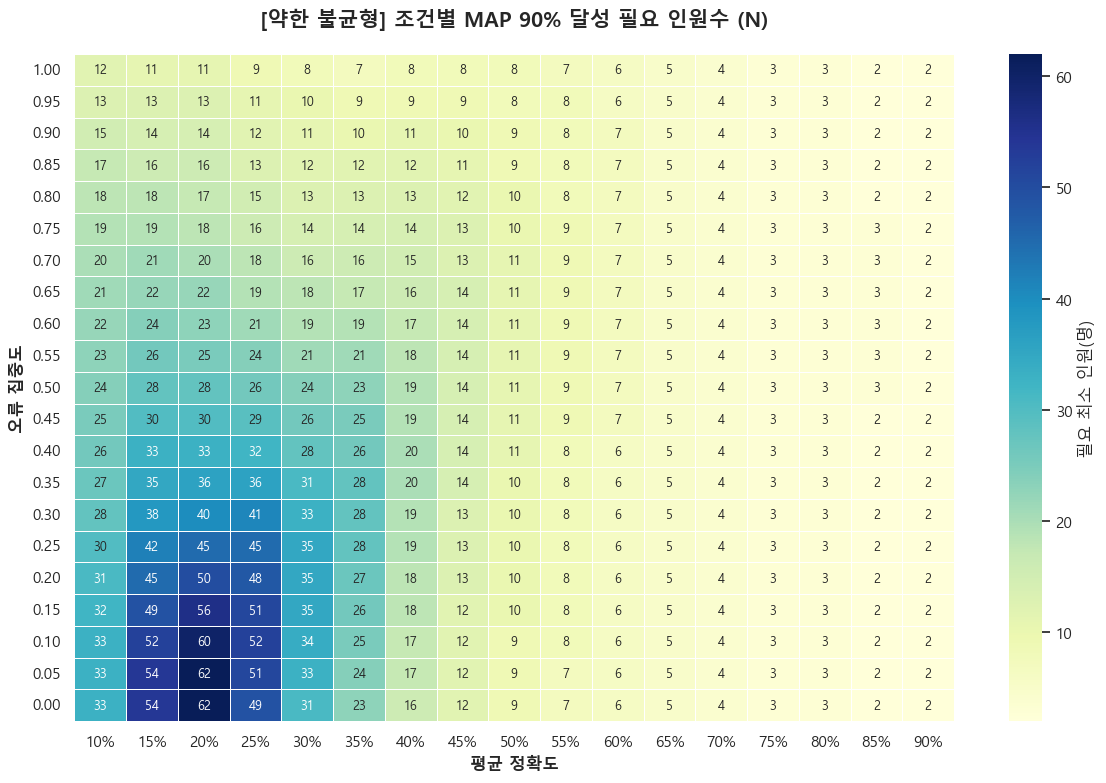

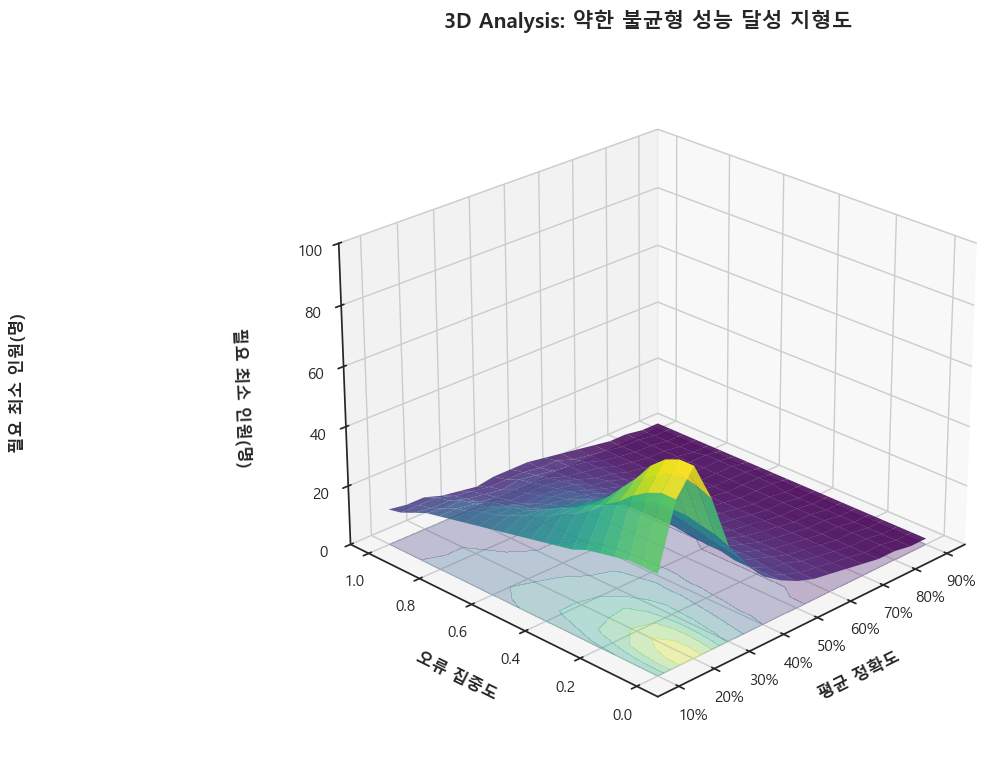

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from matplotlib import cm
from matplotlib import font_manager
from matplotlib.ticker import FuncFormatter

# =========================================================
# 0. 한글 폰트 설정
# =========================================================
available_fonts = {f.name for f in font_manager.fontManager.ttflist}

for font_name in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR']:
    if font_name in available_fonts:
        KOREAN_FONT = font_name
        break
else:
    KOREAN_FONT = None

print("선택된 폰트:", KOREAN_FONT)

if KOREAN_FONT is not None:
    matplotlib.rcParams['font.family'] = KOREAN_FONT
    matplotlib.rcParams['axes.unicode_minus'] = False
else:
    print("한글 폰트를 찾지 못했습니다. 설치된 폰트를 확인해주세요.")

# =========================================================
# 1. 데이터 준비 (기존 threshold_rows_surface 활용)
# =========================================================
df_surface = pd.DataFrame(threshold_rows_surface)

# Pivot 테이블 생성
pivot_df = df_surface.pivot(index='focus_ratio', columns='mean_acc', values='N_map_90')
pivot_df.columns = [f'{c:.0%}' for c in pivot_df.columns]
pivot_df.index = [f'{i:.2f}' for i in pivot_df.index]

# =========================================================
# 시각화 A: 2D Annotated Heatmap
# =========================================================
sns.set_theme(
    style="white",
    rc={
        "font.family": KOREAN_FONT,
        "axes.unicode_minus": False
    }
)

plt.figure(figsize=(12, 8))

ax = sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=.5,
    cbar_kws={'label': '필요 최소 인원(명)'},
    annot_kws={"size": 9}
)

# 오류 집중도(y축) 숫자를 가로로 고정
ax.tick_params(axis='y', labelrotation=0)

plt.title(f'[{FIXED_CLASS_SCENARIO_NAME}] 조건별 MAP 90% 달성 필요 인원수 (N)', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('평균 정확도', fontsize=12, fontweight='bold')
plt.ylabel('오류 집중도', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# =========================================================
# 시각화 B: Improved 3D Surface
# =========================================================
with plt.style.context('seaborn-v0_8-white'):
    # style context 안에서 폰트 다시 지정해야 덮어쓰기 방지됨
    if KOREAN_FONT is not None:
        plt.rcParams['font.family'] = KOREAN_FONT
        plt.rcParams['axes.unicode_minus'] = False

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 3D용 데이터 재구성
    X_vals = x_levels
    Y_vals = y_levels
    X_grid, Y_grid = np.meshgrid(X_vals, Y_vals)
    Z_grid = Z.T  # meshgrid에 맞게 전치

    # Surface
    surf = ax.plot_surface(
        X_grid, Y_grid, Z_grid,
        cmap='viridis',
        edgecolor='none',
        alpha=0.85,
        antialiased=True,
        rcount=100, ccount=100
    )

    # 바닥 등고선
    offset = 0
    ax.contourf(
        X_grid, Y_grid, Z_grid,
        zdir='z',
        offset=offset,
        cmap='viridis',
        alpha=0.30
    )

    # 축 라벨
    ax.set_xlabel('평균 정확도', labelpad=12, fontweight='bold')
    ax.set_ylabel('오류 집중도', labelpad=12, fontweight='bold')
    ax.set_zlabel('필요 최소 인원(명)', labelpad=22, fontweight='bold')

    # 축 범위
    ax.set_zlim(0, 100)

    # z축 숫자에는 단위를 붙이지 않음
    z_ticks = np.arange(0, 101, 20)
    ax.set_zticks(z_ticks)
    ax.set_zticklabels([f'{int(v)}' for v in z_ticks])

    # x축 퍼센트 표시
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.0%}'))
    # y축 소수점 표시
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y:.1f}'))

    # 보기 각도
    ax.view_init(elev=25, azim=-135)

    # 컬러바는 숨기고, 3D 축을 오른쪽으로 이동해 z축 라벨 가시성 확보
    ax.set_position([0.19, 0.10, 0.78, 0.80])

    # 기본 z축 라벨이 잘릴 수 있어 고정 세로 라벨을 추가
    fig.text(0.035, 0.52, '필요 최소 인원(명)', rotation=90, va='center', ha='center', fontweight='bold')

    plt.title(f'3D Analysis: {FIXED_CLASS_SCENARIO_NAME} 성능 달성 지형도', fontsize=15, pad=25, fontweight='bold')
    fig.subplots_adjust(left=0.14, right=0.98, bottom=0.06, top=0.92)
    plt.show()

### 9-1. 95%달성

focused_cms / log_cms 캐시 생성 중...
focused_cms / log_cms 캐시 완료 ✓
디스크 캐시 재사용 ✓  (c:\Users\최현준\Desktop\Projects\pseudo_GT\_threshold_cache\surface_map90_bd92d2633e67273947e92744874dbc40.pkl)


C:\Users\최현준\AppData\Local\Temp\ipykernel_18108\2857200966.py:482: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


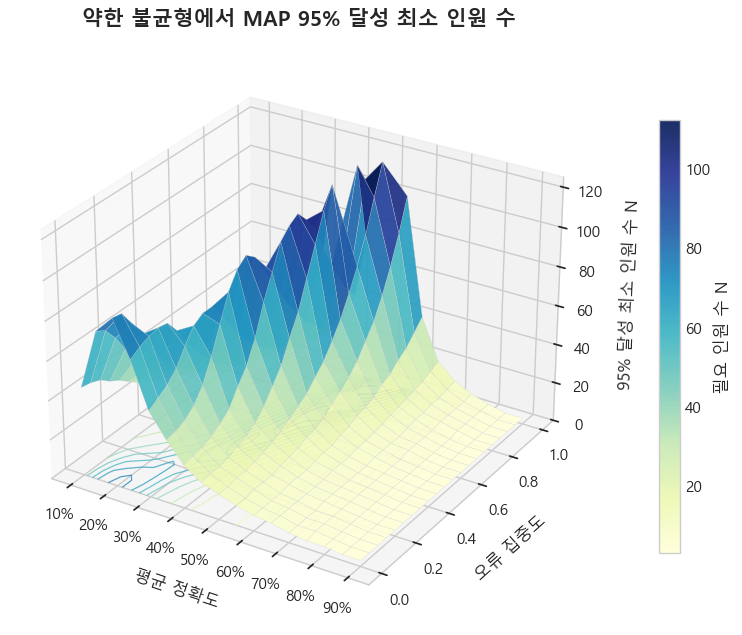

[MAP 95% 달성 최소 인원 수 요약표]
     평균정확도      오류집중도     최종MAP@20      N95
----------------------------------------------
      10%      0.00      99.94%       45
      10%      0.05      99.96%       44
      10%      0.10      99.96%       42
      10%      0.15      99.99%       38
      10%      0.20      99.99%       35
      10%      0.25     100.00%       31
      10%      0.30     100.00%       27
      10%      0.35     100.00%       24
      10%      0.40     100.00%       22
      10%      0.45     100.00%       20
      10%      0.50     100.00%       17
      10%      0.55     100.00%       16
      10%      0.60     100.00%       14
      10%      0.65     100.00%       13
      10%      0.70     100.00%       11
      10%      0.75     100.00%       10
      10%      0.80     100.00%        9
      10%      0.85     100.00%        8
      10%      0.90     100.00%        7
      10%      0.95     100.00%        6
      10%      1.00     100.00%        5
      15%      0.00    

In [19]:
# %% [markdown]
# ## Fast Surface (MAP, N90 only)
# 평균 정확도 5% 단위 × 오류 집중도 0.05 단위에서
# 약한 불균형 분포 고정, MAP이 90% 정확도를 달성하는 데 필요한 최소 인원 수 N 계산

# %%
import os
import pickle
import hashlib
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import font_manager


# =========================================================
# 0. 필수 심볼 확인
# =========================================================
required_symbols = [
    'generate_annotator_confusion_matrices',
]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise ValueError(
        '먼저 앞쪽 기본 함수 셀들을 실행해주세요. 누락 심볼: ' + ', '.join(missing_symbols)
    )


# =========================================================
# 1. 로컬 설정
# =========================================================
# ---- 고정 시나리오 ----
FIXED_CLASS_SCENARIO_NAME = '약한 불균형'
CLASS_PROBS_FIXED = np.array([0.35, 0.25, 0.15, 0.10, 0.10, 0.05], dtype=float)
CLASS_PROBS_FIXED = CLASS_PROBS_FIXED / CLASS_PROBS_FIXED.sum()

# ---- 목표 정확도 ----
THRESHOLD_TAU = 0.95
SHOW_METHOD = 'map'    # 이 코드는 현재 MAP만 계산

# ---- 격자 ----
x_levels = np.round(np.arange(0.10, 0.901, 0.05), 2)   # 평균 정확도: 10% ~ 90%, 5% 단위
y_levels = np.round(np.arange(0.00, 1.001, 0.05), 2)   # 오류 집중도: 0.00 ~ 1.00, 0.05 단위

# ---- 실험 기본값 ----
N_POOL_SURFACE = 120
NUM_SAMPLES_SURFACE = NUM_SAMPLES if 'NUM_SAMPLES' in globals() else 5000
NUM_CLASSES_SURFACE = NUM_CLASSES if 'NUM_CLASSES' in globals() else 6
SEED_BASE_SURFACE = SEED if 'SEED' in globals() else 42

# ---- 이 실험 전용 seed ----
SEED_LIST_SURFACE = [42, 52, 62, 72, 82, 92, 102, 112, 122, 132]

# ---- 오류 집중 쌍 ----
# 논문에서 쓰던 구조적 혼동 쌍 기준으로 맞춰둠
CONFUSABLE_PAIRS_FIXED = [(0, 1), (3, 4)]

# ---- 병렬화 ----
USE_PARALLEL = True
PARALLEL_BACKEND = 'thread'   # 기본 추천: thread
MAX_WORKERS = min(len(x_levels) * len(y_levels), max(1, (os.cpu_count() or 1) - 1))

if PARALLEL_BACKEND not in ('thread', 'process'):
    raise ValueError("PARALLEL_BACKEND는 'thread' 또는 'process' 이어야 합니다.")

# ---- 캐시 ----
USE_DISK_CACHE = True
CACHE_DIR = os.path.join(os.getcwd(), "_threshold_cache")
os.makedirs(CACHE_DIR, exist_ok=True)

# ---- 폰트 ----
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR']:
    if font_name in available_fonts:
        KOREAN_FONT_SURFACE = font_name
        break
else:
    KOREAN_FONT_SURFACE = None

if KOREAN_FONT_SURFACE is not None:
    matplotlib.rcParams['font.family'] = KOREAN_FONT_SURFACE
    matplotlib.rcParams['axes.unicode_minus'] = False


# =========================================================
# 2. 로컬 유틸
# =========================================================
def make_homogeneous_target_cfg(n_annotators, target_acc):
    return {
        f'균질 그룹 ({target_acc:.0%})': (int(n_annotators), float(target_acc)),
    }

def smooth_confusion_matrices_local(cms, epsilon=1e-12):
    smoothed = []
    for cm in cms:
        s = np.asarray(cm, dtype=float).copy() + epsilon
        s /= s.sum(axis=1, keepdims=True)
        smoothed.append(s)
    return smoothed

def precompute_log_cms_local(confusion_matrices, epsilon=1e-12):
    smoothed = smooth_confusion_matrices_local(confusion_matrices, epsilon)
    return np.stack([np.log(cm) for cm in smoothed], axis=0)   # (A, K, K)

def simulate_responses_vectorized_local(confusion_matrices, true_labels, seed=None):
    rng = np.random.default_rng(seed)
    true_labels = np.asarray(true_labels, dtype=int)

    num_samples = true_labels.shape[0]
    num_ann = len(confusion_matrices)
    responses = np.empty((num_samples, num_ann), dtype=np.int16)

    for i, cm in enumerate(confusion_matrices):
        probs = np.asarray(cm, dtype=float)[true_labels]   # (N, K)
        cdf = np.cumsum(probs, axis=1)
        cdf[:, -1] = 1.0
        u = rng.random(num_samples)[:, None]
        responses[:, i] = np.argmax(u <= cdf, axis=1)

    return responses

def apply_focus_sweep_pattern_local(cm, confusable_pairs, focus_ratio):
    """
    대각 성분은 유지한 채, 오프대각 오류 질량을
    focus_ratio에 따라 특정 혼동쌍으로 집중시키는 함수
    """
    if not (0.0 <= float(focus_ratio) <= 1.0):
        raise ValueError('focus_ratio는 [0, 1] 범위여야 합니다.')

    base = np.asarray(cm, dtype=float)
    k = base.shape[0]
    out = base.copy()

    for src in range(k):
        diag = float(base[src, src])
        off_sum = max(0.0, 1.0 - diag)

        row = np.zeros(k, dtype=float)
        row[src] = diag

        if off_sum <= 0.0:
            out[src] = row
            continue

        off_idx = [j for j in range(k) if j != src]

        w_base = base[src, off_idx].astype(float)
        s_base = float(w_base.sum())
        if s_base <= 0:
            w_base = np.ones(len(off_idx), dtype=float) / len(off_idx)
        else:
            w_base = w_base / s_base

        pair_targets = []
        for a, b in confusable_pairs:
            a = int(a)
            b = int(b)
            if src == a:
                pair_targets.append(b)
            elif src == b:
                pair_targets.append(a)

        w_focus = np.zeros(len(off_idx), dtype=float)
        for idx, tgt in enumerate(off_idx):
            if tgt in pair_targets:
                w_focus[idx] = 1.0

        if float(w_focus.sum()) <= 0:
            w_focus = w_base.copy()
        else:
            w_focus = w_focus / float(w_focus.sum())

        w_mix = (1.0 - float(focus_ratio)) * w_base + float(focus_ratio) * w_focus
        w_mix = w_mix / float(w_mix.sum())

        row[off_idx] = off_sum * w_mix
        out[src] = row

    out = np.clip(out, 0.0, 1.0)
    out = out / out.sum(axis=1, keepdims=True)
    return out

def find_min_n_for_threshold(curve_values, annotator_counts, tau):
    curve_values = np.asarray(curve_values, dtype=float)
    annotator_counts = np.asarray(annotator_counts, dtype=int)

    hit_idx = np.where(curve_values >= float(tau))[0]
    if len(hit_idx) == 0:
        return np.nan
    return float(annotator_counts[hit_idx[0]])

def build_cache_key():
    key_obj = {
        "scenario": FIXED_CLASS_SCENARIO_NAME,
        "tau": THRESHOLD_TAU,
        "x_levels": tuple(np.round(x_levels, 6)),
        "y_levels": tuple(np.round(y_levels, 6)),
        "n_pool": int(N_POOL_SURFACE),
        "num_samples": int(NUM_SAMPLES_SURFACE),
        "num_classes": int(NUM_CLASSES_SURFACE),
        "seed_list": tuple(SEED_LIST_SURFACE),
        "pairs": tuple(CONFUSABLE_PAIRS_FIXED),
        "off_alpha": float(OFF_ALPHA),
        "target_base_diag_alpha": float(TARGET_BASE_DIAG_ALPHA),
        "diag_spread": float(DIAG_SPREAD),
        "target_offdiag_alpha": float(TARGET_OFFDIAG_ALPHA),
    }
    key_repr = repr(key_obj).encode("utf-8")
    return hashlib.md5(key_repr).hexdigest(), key_obj


# =========================================================
# 3. seed payload 미리 생성
#    - true_labels
#    - prior / log_prior
#    - annotator permutation
# =========================================================
seed_payloads = {}
for seed in SEED_LIST_SURFACE:
    rng_labels = np.random.default_rng(int(seed + 1))
    true_labels = rng_labels.choice(
        NUM_CLASSES_SURFACE,
        size=NUM_SAMPLES_SURFACE,
        p=CLASS_PROBS_FIXED,
    ).astype(np.int16)

    prior = np.bincount(true_labels, minlength=NUM_CLASSES_SURFACE).astype(float)
    prior /= prior.sum()
    log_prior = np.log(prior + 1e-300)

    rng_perm = np.random.default_rng(int(seed + 20000))
    perm = rng_perm.permutation(N_POOL_SURFACE).astype(np.int16)

    seed_payloads[int(seed)] = {
        "true_labels": true_labels,
        "prior": prior,
        "log_prior": log_prior,
        "perm": perm,
        "response_seed": int(seed + 2),
    }


# =========================================================
# 4. mean_acc별 base confusion matrix 1회 생성
# =========================================================
base_cms_by_acc = {}
for mean_acc in x_levels:
    target_cfg = make_homogeneous_target_cfg(
        n_annotators=N_POOL_SURFACE,
        target_acc=float(mean_acc),
    )

    base_cms, _, n_ann = generate_annotator_confusion_matrices(
        num_classes=NUM_CLASSES_SURFACE,
        annotator_config=ANNOTATOR_CONFIG,
        seed=int(SEED_BASE_SURFACE + 610000 + round(float(mean_acc) * 1000)),
        cm_generation_mode='target_accuracy',
        off_alpha=OFF_ALPHA,
        target_acc=float(mean_acc),
        target_annotator_config=target_cfg,
        accuracy_mode='uniform_weighted',
        target_base_diag_alpha=TARGET_BASE_DIAG_ALPHA,
        diag_spread=DIAG_SPREAD,
        target_offdiag_alpha=TARGET_OFFDIAG_ALPHA,
    )

    if int(n_ann) != int(N_POOL_SURFACE):
        raise ValueError(
            f'평균 정확도 {mean_acc:.2f} 조건에서 어노테이터 수가 {N_POOL_SURFACE}명이 아닙니다: {n_ann}'
        )

    base_cms_by_acc[float(mean_acc)] = base_cms


# =========================================================
# 5. (mean_acc, focus_ratio)별 focused CM / log CM 캐시
# =========================================================
focused_cms_cache = {}
log_cms_cache = {}

print("focused_cms / log_cms 캐시 생성 중...")
for mean_acc in x_levels:
    base_cms = base_cms_by_acc[float(mean_acc)]

    for focus_ratio in y_levels:
        cond_key = (float(mean_acc), float(focus_ratio))

        focused_cms = [
            apply_focus_sweep_pattern_local(
                cm.copy(),
                CONFUSABLE_PAIRS_FIXED,
                focus_ratio=float(focus_ratio),
            )
            for cm in base_cms
        ]

        focused_cms_cache[cond_key] = focused_cms
        log_cms_cache[cond_key] = precompute_log_cms_local(focused_cms)

print("focused_cms / log_cms 캐시 완료 ✓")


# =========================================================
# 6. 조건 하나 계산
#    - MAP만
#    - N90만
#    - seed payload 재사용
# =========================================================
def compute_one_condition_fast(cond_key):
    mean_acc, focus_ratio = cond_key
    focused_cms = focused_cms_cache[(float(mean_acc), float(focus_ratio))]
    log_cms = log_cms_cache[(float(mean_acc), float(focus_ratio))]

    num_annotators = len(focused_cms)
    annotator_counts = np.arange(1, num_annotators + 1, dtype=int)

    map_curve_sum = np.zeros(num_annotators, dtype=float)

    for seed in SEED_LIST_SURFACE:
        payload = seed_payloads[int(seed)]
        true_labels = payload["true_labels"]
        log_prior = payload["log_prior"]
        perm = payload["perm"]
        response_seed = payload["response_seed"]

        responses = simulate_responses_vectorized_local(
            focused_cms,
            true_labels,
            seed=response_seed,
        )

        responses = responses[:, perm]
        log_cms_perm = log_cms[perm]

        cum_log_like = np.zeros((NUM_SAMPLES_SURFACE, NUM_CLASSES_SURFACE), dtype=float)

        for idx in range(num_annotators):
            observed = responses[:, idx].astype(int)
            cum_log_like += log_cms_perm[idx, :, observed]

            preds_map = np.argmax(cum_log_like + log_prior, axis=1).astype(np.int16)
            map_curve_sum[idx] += float(np.mean(preds_map == true_labels))

    map_curve_mean = map_curve_sum / len(SEED_LIST_SURFACE)
    n90 = find_min_n_for_threshold(map_curve_mean, annotator_counts, THRESHOLD_TAU)

    return {
        "class_scenario": FIXED_CLASS_SCENARIO_NAME,
        "mean_acc": float(mean_acc),
        "focus_ratio": float(focus_ratio),
        "final_map_acc": float(map_curve_mean[-1]),
        "N_map_90": n90,
    }


# =========================================================
# 7. 캐시 로드 / 계산
# =========================================================
cache_hash, cache_key_obj = build_cache_key()
cache_path = os.path.join(CACHE_DIR, f"surface_map90_{cache_hash}.pkl")

threshold_rows_surface = None

if USE_DISK_CACHE and os.path.exists(cache_path):
    try:
        with open(cache_path, "rb") as f:
            payload = pickle.load(f)
        if payload.get("cache_key_obj") == cache_key_obj:
            threshold_rows_surface = payload["rows"]
            print(f"디스크 캐시 재사용 ✓  ({cache_path})")
    except Exception as e:
        print("캐시 로드 실패, 새로 계산합니다:", e)

if threshold_rows_surface is None:
    print("surface threshold 새로 계산 중...")

    grid_args = [(float(mx), float(fy)) for mx in x_levels for fy in y_levels]

    if USE_PARALLEL and len(grid_args) > 1:
        executor_cls = ThreadPoolExecutor if PARALLEL_BACKEND == 'thread' else ProcessPoolExecutor
        with executor_cls(max_workers=MAX_WORKERS) as ex:
            threshold_rows_surface = list(ex.map(compute_one_condition_fast, grid_args))
    else:
        threshold_rows_surface = [compute_one_condition_fast(args) for args in grid_args]

    if USE_DISK_CACHE:
        with open(cache_path, "wb") as f:
            pickle.dump(
                {
                    "cache_key_obj": cache_key_obj,
                    "rows": threshold_rows_surface,
                },
                f,
            )
        print(f"디스크 캐시 저장 완료 ✓  ({cache_path})")


# =========================================================
# 8. surface용 Z 행렬 생성
# =========================================================
def get_required_n_surface(rows, mean_acc, focus_ratio):
    for row in rows:
        if (
            np.isclose(row["mean_acc"], float(mean_acc)) and
            np.isclose(row["focus_ratio"], float(focus_ratio))
        ):
            return row["N_map_90"]
    return np.nan

X, Y = np.meshgrid(x_levels, y_levels, indexing='ij')
Z = np.full((len(x_levels), len(y_levels)), np.nan, dtype=float)

for i, mean_acc in enumerate(x_levels):
    for j, focus_ratio in enumerate(y_levels):
        Z[i, j] = get_required_n_surface(
            threshold_rows_surface,
            mean_acc,
            focus_ratio,
        )


# =========================================================
# 9. 그림
# =========================================================
with plt.style.context('seaborn-v0_8-whitegrid'):
    if KOREAN_FONT_SURFACE is not None:
        plt.rcParams['font.family'] = KOREAN_FONT_SURFACE
        plt.rcParams['axes.unicode_minus'] = False

    fig = plt.figure(figsize=(11.5, 7.5))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        X, Y, Z,
        cmap='YlGnBu',
        edgecolor='#d0d0d0',
        linewidth=0.18,
        antialiased=True,
        alpha=0.92,
    )

    # 바닥면 contour projection으로 높이 변화를 쉽게 읽도록 보조
    z_floor = 0.0
    ax.contour(
        X, Y, Z,
        zdir='z',
        offset=z_floor,
        levels=12,
        cmap='YlGnBu',
        linewidths=0.9,
        alpha=0.75,
    )

    ax.set_xlabel('평균 정확도', labelpad=10)
    ax.set_ylabel('오류 집중도', labelpad=10)
    ax.set_zlabel('95% 달성 최소 인원 수 N', labelpad=10)

    ax.set_xticks(np.arange(0.10, 0.91, 0.10))
    ax.set_xticklabels([f'{v:.0%}' for v in np.arange(0.10, 0.91, 0.10)])

    ax.set_yticks(np.arange(0.0, 1.01, 0.2))
    ax.set_yticklabels([f'{v:.1f}' for v in np.arange(0.0, 1.01, 0.2)])

    z_data_max = float(np.nanmax(Z)) if np.any(np.isfinite(Z)) else float(N_POOL_SURFACE)
    z_upper = max(5.0, float(np.ceil((z_data_max + 5.0) / 5.0) * 5.0))
    ax.set_zlim(z_floor, z_upper)
    ax.view_init(elev=28, azim=-58)

    cbar = fig.colorbar(surf, shrink=0.75, pad=0.08)
    cbar.set_label('필요 인원 수 N')

    ax.set_title(
        f'{FIXED_CLASS_SCENARIO_NAME}에서 MAP 95% 달성 최소 인원 수',
        fontsize=15,
        fontweight='bold',
        pad=16,
    )

    plt.tight_layout()
    plt.show()


# =========================================================
# 10. 표 출력
# =========================================================
print('[MAP 95% 달성 최소 인원 수 요약표]')
print(f"{'평균정확도':>10} {'오류집중도':>10} {'최종MAP@20':>12} {'N95':>8}")
print('-' * 46)
for row in sorted(threshold_rows_surface, key=lambda r: (r['mean_acc'], r['focus_ratio'])):
    n90_txt = '-' if np.isnan(row['N_map_90']) else str(int(row['N_map_90']))
    print(
        f"{row['mean_acc']:>9.0%} "
        f"{row['focus_ratio']:>9.2f} "
        f"{row['final_map_acc']:>11.2%} "
        f"{n90_txt:>8}"
    )

캐시 재사용: c:\Users\최현준\Desktop\Projects\pseudo_GT\_threshold_cache\scatter_req_n_by_target_5d3ddce8e583537b33970cc79b94867a.pkl


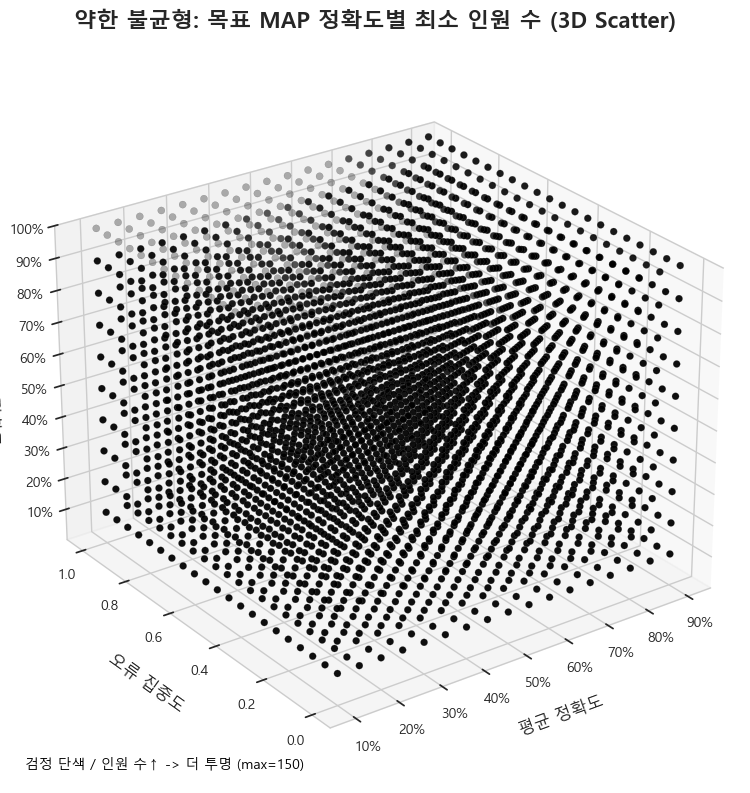


[예시 조건 확인: mean_acc=10%, focus_ratio=0.0]
target=10% -> required_n=1
target=20% -> required_n=1
target=30% -> required_n=1
target=40% -> required_n=2
target=50% -> required_n=6
target=60% -> required_n=10
target=70% -> required_n=15
target=80% -> required_n=22
target=90% -> required_n=33
target=100% -> required_n=-


In [20]:
# Fast Scatter (z축=목표 MAP 정확도, 점 투명도=해당 정확도 달성 최소 인원 수)
import os
import pickle
import hashlib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

required_vars = ['focused_cms_cache', 'log_cms_cache', 'seed_payloads', 'SEED_LIST_SURFACE', 'NUM_SAMPLES_SURFACE', 'NUM_CLASSES_SURFACE']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(
        '이 셀은 Fast Surface 계산 셀 이후 실행해야 합니다. 누락 변수: ' + ', '.join(missing)
    )

# 폰트
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'Noto Sans CJK KR']:
    if font_name in available_fonts:
        KOREAN_FONT_SURFACE = font_name
        break
else:
    KOREAN_FONT_SURFACE = None

if KOREAN_FONT_SURFACE is not None:
    matplotlib.rcParams['font.family'] = KOREAN_FONT_SURFACE
    matplotlib.rcParams['axes.unicode_minus'] = False

# 설정
TARGET_MAP_LEVELS = np.round(np.arange(0.10, 1.001, 0.10), 2)  # z축 레벨
MAX_N_DISPLAY = 150.0  # 표시용 상한
ALPHA_MIN, ALPHA_MAX = 0.30, 0.95

CACHE_DIR = os.path.join(os.getcwd(), '_threshold_cache')
os.makedirs(CACHE_DIR, exist_ok=True)

def _find_min_n_for_threshold(curve_values, tau):
    curve_values = np.asarray(curve_values, dtype=float)
    hit = np.where(curve_values >= float(tau))[0]
    if len(hit) == 0:
        return np.nan
    return float(hit[0] + 1)  # n starts at 1

def _simulate_responses_vectorized_local(confusion_matrices, true_labels, seed=None):
    rng = np.random.default_rng(seed)
    true_labels = np.asarray(true_labels, dtype=int)

    num_samples = true_labels.shape[0]
    num_ann = len(confusion_matrices)
    responses = np.empty((num_samples, num_ann), dtype=np.int16)

    for i, cm in enumerate(confusion_matrices):
        probs = np.asarray(cm, dtype=float)[true_labels]
        cdf = np.cumsum(probs, axis=1)
        cdf[:, -1] = 1.0
        u = rng.random(num_samples)[:, None]
        responses[:, i] = np.argmax(u <= cdf, axis=1)

    return responses

def _compute_map_curve_mean_from_cache(cond_key):
    cond_key = (float(cond_key[0]), float(cond_key[1]))
    focused_cms = focused_cms_cache[cond_key]
    log_cms = log_cms_cache[cond_key]

    num_annotators = len(focused_cms)
    map_curve_sum = np.zeros(num_annotators, dtype=float)

    for seed in SEED_LIST_SURFACE:
        payload = seed_payloads[int(seed)]
        true_labels = payload['true_labels']
        log_prior = payload['log_prior']
        perm = payload['perm']
        response_seed = payload['response_seed']

        responses = _simulate_responses_vectorized_local(
            focused_cms,
            true_labels,
            seed=response_seed,
        )

        responses = responses[:, perm]
        log_cms_perm = log_cms[perm]

        cum_log_like = np.zeros((NUM_SAMPLES_SURFACE, NUM_CLASSES_SURFACE), dtype=float)

        for idx in range(num_annotators):
            observed = responses[:, idx].astype(int)
            cum_log_like += log_cms_perm[idx, :, observed]
            preds_map = np.argmax(cum_log_like + log_prior, axis=1).astype(np.int16)
            map_curve_sum[idx] += float(np.mean(preds_map == true_labels))

    return map_curve_sum / len(SEED_LIST_SURFACE)

# 캐시 키
cond_keys_sorted = sorted(list(focused_cms_cache.keys()), key=lambda t: (float(t[0]), float(t[1])))
cache_key_obj = {
    'cond_count': len(cond_keys_sorted),
    'target_levels': tuple(TARGET_MAP_LEVELS.tolist()),
    'seed_list': tuple([int(s) for s in SEED_LIST_SURFACE]),
    'num_samples': int(NUM_SAMPLES_SURFACE),
    'num_classes': int(NUM_CLASSES_SURFACE),
}
cache_hash = hashlib.md5(repr(cache_key_obj).encode('utf-8')).hexdigest()
cache_path = os.path.join(CACHE_DIR, f'scatter_req_n_by_target_{cache_hash}.pkl')

rows = None
if os.path.exists(cache_path):
    try:
        with open(cache_path, 'rb') as f:
            payload = pickle.load(f)
        if payload.get('cache_key_obj') == cache_key_obj:
            rows = payload['rows']
            print(f'캐시 재사용: {cache_path}')
    except Exception as e:
        print('캐시 로드 실패, 재계산합니다:', e)

if rows is None:
    print('목표 정확도별 최소 인원 수 계산 중...')
    rows = []
    for cond_key in cond_keys_sorted:
        mx, fy = float(cond_key[0]), float(cond_key[1])
        map_curve_mean = _compute_map_curve_mean_from_cache(cond_key)
        for tau in TARGET_MAP_LEVELS:
            n_req = _find_min_n_for_threshold(map_curve_mean, tau)
            rows.append({
                'mean_acc': mx,
                'focus_ratio': fy,
                'target_map_acc': float(tau),
                'required_n': n_req,
            })

    with open(cache_path, 'wb') as f:
        pickle.dump({'cache_key_obj': cache_key_obj, 'rows': rows}, f)
    print(f'캐시 저장 완료: {cache_path}')

# 1D 벡터 구성
x_sc = np.array([r['mean_acc'] for r in rows], dtype=float)
y_sc = np.array([r['focus_ratio'] for r in rows], dtype=float)
z_sc = np.array([r['target_map_acc'] for r in rows], dtype=float)
n_sc = np.array([r['required_n'] for r in rows], dtype=float)

# 미도달은 최대치로 처리
n_display = n_sc.copy()
n_display[np.isnan(n_display)] = MAX_N_DISPLAY
n_display = np.clip(n_display, 0.0, MAX_N_DISPLAY)

# 검정 단색 + 인원 수가 많을수록 더 투명
alpha_sc = ALPHA_MAX - (n_display / MAX_N_DISPLAY) * (ALPHA_MAX - ALPHA_MIN)
rgba = np.zeros((len(n_display), 4), dtype=float)
rgba[:, 3] = alpha_sc

with plt.style.context('seaborn-v0_8-whitegrid'):
    if KOREAN_FONT_SURFACE is not None:
        plt.rcParams['font.family'] = KOREAN_FONT_SURFACE
        plt.rcParams['axes.unicode_minus'] = False

    fig = plt.figure(figsize=(12.2, 8.2))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        x_sc, y_sc, z_sc,
        c=rgba,
        s=26,
        marker='o',
        edgecolors='#5f5f5f',
        linewidths=0.14,
        depthshade=False,
    )

    ax.set_xlabel('평균 정확도', labelpad=12, fontsize=12)
    ax.set_ylabel('오류 집중도', labelpad=12, fontsize=12)
    ax.set_zlabel('목표 MAP 정확도', labelpad=10, fontsize=12)

    ax.set_xticks(np.arange(0.10, 0.91, 0.10))
    ax.set_xticklabels([f'{v:.0%}' for v in np.arange(0.10, 0.91, 0.10)], fontsize=10)
    ax.set_yticks(np.arange(0.0, 1.01, 0.2))
    ax.set_yticklabels([f'{v:.1f}' for v in np.arange(0.0, 1.01, 0.2)], fontsize=10)
    ax.set_zlim(0.0, 1.0)
    ax.set_zticks(TARGET_MAP_LEVELS)
    ax.set_zticklabels([f'{v:.0%}' for v in TARGET_MAP_LEVELS], fontsize=10)

    ax.view_init(elev=26, azim=-126)

    title_scenario = globals().get('FIXED_CLASS_SCENARIO_NAME', '시나리오')
    ax.set_title(
        f'{title_scenario}: 목표 MAP 정확도별 최소 인원 수 (3D Scatter)',
        fontsize=16,
        fontweight='bold',
        pad=18,
    )

    ax.text2D(
        0.02, 0.02,
        '검정 단색 / 인원 수↑ -> 더 투명 (max=150)',
        transform=ax.transAxes,
        fontsize=10,
        color='black',
    )

    fig.subplots_adjust(left=0.02, right=0.97, bottom=0.03, top=0.92)
    plt.show()

# 사용자 예시 조건 확인 출력
query = [r for r in rows if abs(r['mean_acc'] - 0.10) < 1e-12 and abs(r['focus_ratio'] - 0.0) < 1e-12]
if query:
    print('\n[예시 조건 확인: mean_acc=10%, focus_ratio=0.0]')
    for r in sorted(query, key=lambda d: d['target_map_acc']):
        n_txt = '-' if np.isnan(r['required_n']) else str(int(r['required_n']))
        print(f"target={r['target_map_acc']:.0%} -> required_n={n_txt}")